# Time series — companion notebook

Runnable Python examples for every topic in `timeseries.pdf` (Francisco Förster, AS4501).
Each section heading matches a slide title; the `📖 PDF page N` marker tells you where in the PDF to look.

Covers two 1.5-hr classes:
- **Class 1 — Part I** Stochastic autoregressive models
- **Class 2 — Part II** Fourier analysis & period finding


## Setup

Imports, RNG seed, and matplotlib defaults. Run this cell once at the start of class.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import signal, stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.stattools import durbin_watson

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA = Path('data')


# ---- Lomb-Scargle helpers ---------------------------------------------------
# We use scipy.signal.lombscargle. It takes ANGULAR frequencies (rad / unit time).
#   floating_mean=True   → generalized LS (Zechmeister & Kürster 2009)
#   weights=1/sigma²     → heteroscedastic weighting
# For multi-term (truncated Fourier) LS we hand-roll a weighted least-squares fit.

def lomb_scargle(t, y, sigma=None, freq=None, fit_mean=True,
                 minimum_frequency=None, maximum_frequency=None,
                 samples_per_peak=5):
    """Linear-frequency wrapper around scipy.signal.lombscargle.

    Grid spacing is set by the BASELINE T = t.max() - t.min(), not by
    minimum_frequency — the natural peak width of LS is ~1/T regardless
    of where the search starts. Without this, narrow peaks at high
    frequency get missed and the recovered period can be off by enough
    to destroy a phase fold over long baselines.
    """
    if freq is None:
        T = t.max() - t.min()
        dt_med = np.median(np.diff(np.sort(t)))
        f_min = 1.0 / T if minimum_frequency is None else minimum_frequency
        f_max = 1.0 / (2 * dt_med) if maximum_frequency is None else maximum_frequency
        df = (1.0 / T) / samples_per_peak
        freq = np.arange(f_min, f_max + df, df)
    omega = 2 * np.pi * np.asarray(freq)
    w = None if sigma is None else 1.0 / np.asarray(sigma) ** 2
    power = signal.lombscargle(t, y, omega, weights=w,
                               floating_mean=fit_mean, normalize='normalize')
    return np.asarray(freq), power

def multiterm_design(t, freq, nterms):
    cols = [np.ones_like(t)]
    for k in range(1, nterms + 1):
        cols.append(np.sin(2 * np.pi * k * freq * t))
        cols.append(np.cos(2 * np.pi * k * freq * t))
    return np.column_stack(cols)

def multiterm_power(t, y, sigma, freq, nterms):
    """Power = 1 - chi²_model / chi²_null for the multi-term model."""
    w = 1.0 / np.asarray(sigma) ** 2
    sw = np.sqrt(w)
    y_bar = np.sum(w * y) / np.sum(w)
    chi2_null = float(np.sum(w * (y - y_bar) ** 2))
    out = np.empty_like(freq, dtype=float)
    for i, f in enumerate(freq):
        A = multiterm_design(t, f, nterms)
        c, *_ = np.linalg.lstsq(A * sw[:, None], y * sw, rcond=None)
        chi2 = float(np.sum(w * (y - A @ c) ** 2))
        out[i] = 1 - chi2 / chi2_null
    return out

def multiterm_model(t, y, sigma, freq_best, nterms, t_eval):
    """Fit multi-term Fourier model at freq_best, evaluate on t_eval."""
    w = 1.0 / np.asarray(sigma) ** 2
    sw = np.sqrt(w)
    A = multiterm_design(t, freq_best, nterms)
    c, *_ = np.linalg.lstsq(A * sw[:, None], y * sw, rcond=None)
    return multiterm_design(t_eval, freq_best, nterms) @ c

print('Setup OK')

Setup OK


---
# Part I — Stochastic autoregressive models
*PDF pages 1–50*

## 1. Bibliography
> 📖 PDF page 3

- *Modern Statistical Methods for Astronomy, with R Applications* — E. Feigelson & G. Babu
- *Statistics, Data Mining, and Machine Learning in Astronomy* — Z. Ivezić, A. Connolly, J. VanderPlas, A. Gray


## 2. Variable phenomena
> 📖 PDF pages 4–5

- **Apparent variability** — rotation, orbital motions (geometry changes our view of a constant source)
- **Intrinsic variability** — pulsations, explosions, ejections, accretion (the source itself changes)

The variability tree (Eyer & Mowlavi 2008, updated in Eyer et al. 2018) organizes known classes by physical mechanism. See `images/eyer.png` in this directory.

## 3. Timescales in astronomy
> 📖 PDF page 6

Physical timescales span ~17 orders of magnitude — from microsecond accretion variability to centuries-long binary orbits.

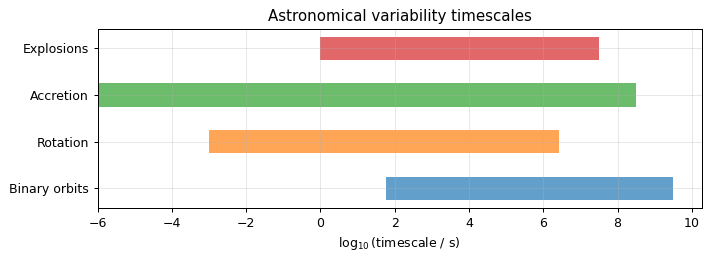

In [2]:
timescales = [
    ('Binary orbits',  60,        100*365.25*86400),  # minutes to centuries
    ('Rotation',       1e-3,      30*86400),          # msec to months
    ('Accretion',      1e-6,      10*365.25*86400),   # μsec to decades
    ('Explosions',     1,         365.25*86400),      # seconds to years
]

fig, ax = plt.subplots(figsize=(8, 3))
for i, (label, lo, hi) in enumerate(timescales):
    ax.barh(i, np.log10(hi) - np.log10(lo), left=np.log10(lo),
            height=0.5, alpha=0.7)
ax.set_yticks(range(len(timescales)))
ax.set_yticklabels([t[0] for t in timescales])
ax.set_xlabel(r'$\log_{10}$(timescale / s)')
ax.set_title('Astronomical variability timescales')
plt.tight_layout(); plt.show()

## 4. Astronomical surveys — etendue
> 📖 PDF pages 7–14

**Etendue** = collecting area × field of view. It is the key figure of merit for a survey telescope: bigger etendue → more sky covered to a given depth in less time.

In [3]:
surveys = pd.DataFrame({
    'name':     ['OmegaCam', 'iPTF', 'SkyMapper', 'PS1', 'DECam', 'HSC',
                 'KMTNet', 'ZTF', 'LSST ComCam', 'LSST'],
    'area_m2':  [5.3,  1.1, 1.4, 2.5, 11.3, 52.8, 2.0,  1.1, 35.7, 35.7],
    'fov_deg2': [1.0,  7.8, 5.7, 3.0, 3.0,  1.5,  4.0, 47.0, 0.4,  9.6],
    'pix_M':    [268,  92,  256, 1400, 520, 870,  340, 576,  144, 3200],
})
surveys['etendue'] = surveys.area_m2 * surveys.fov_deg2
surveys.sort_values('etendue').reset_index(drop=True)

,name,area_m2,fov_deg2,pix_M,etendue
0,OmegaCam,5.3,1.0,268,5.30
1,PS1,2.5,3.0,1400,7.50
2,SkyMapper,1.4,5.7,256,7.98
3,KMTNet,2.0,4.0,340,8.00
4,iPTF,1.1,7.8,92,8.58
5,LSST ComCam,35.7,0.4,144,14.28
6,DECam,11.3,3.0,520,33.90
7,ZTF,1.1,47.0,576,51.70
8,HSC,52.8,1.5,870,79.20
9,LSST,35.7,9.6,3200,342.72


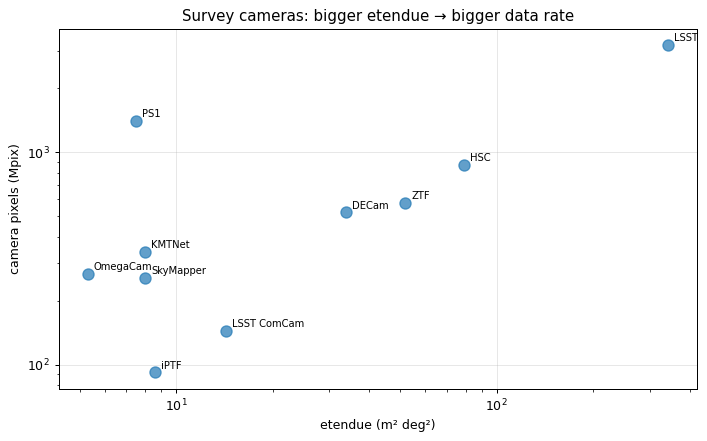

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(surveys.etendue, surveys.pix_M, s=80, c='C0', alpha=0.7)
for _, r in surveys.iterrows():
    ax.annotate(r['name'], (r.etendue, r.pix_M),
                xytext=(5, 3), textcoords='offset points', fontsize=8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('etendue (m² deg²)')
ax.set_ylabel('camera pixels (Mpix)')
ax.set_title('Survey cameras: bigger etendue → bigger data rate')
plt.tight_layout(); plt.show()

## 5. Stochastic processes
> 📖 PDF page 16

A stochastic process is a collection of random variables indexed by time. Two realizations of the *same* process can look very different — what is statistically constant is the *distribution* of realizations, not any single curve.

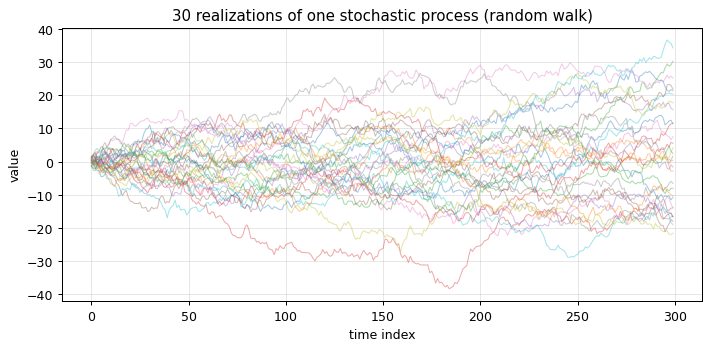

In [5]:
rng = np.random.default_rng(0)
n, n_real = 300, 30
t = np.arange(n)

fig, ax = plt.subplots(figsize=(8, 4))
for _ in range(n_real):
    x = np.cumsum(rng.normal(size=n))  # random walk
    ax.plot(t, x, alpha=0.4, lw=0.8)
ax.set_xlabel('time index'); ax.set_ylabel('value')
ax.set_title(f'{n_real} realizations of one stochastic process (random walk)')
plt.tight_layout(); plt.show()

## 6. Statistical behaviour — $1/f^{\gamma}$ noise
> 📖 PDF page 17

Noise with power spectral density $S(f) \propto 1/f^{\gamma}$:
- $\gamma = 0$ → **white** (no time correlation)
- $\gamma = 1$ → **pink** (long memory; ubiquitous in nature)
- $\gamma = 2$ → **red / brown** (random walk)

Below we generate each by filtering white noise in the frequency domain and verify the slope of the PSD.

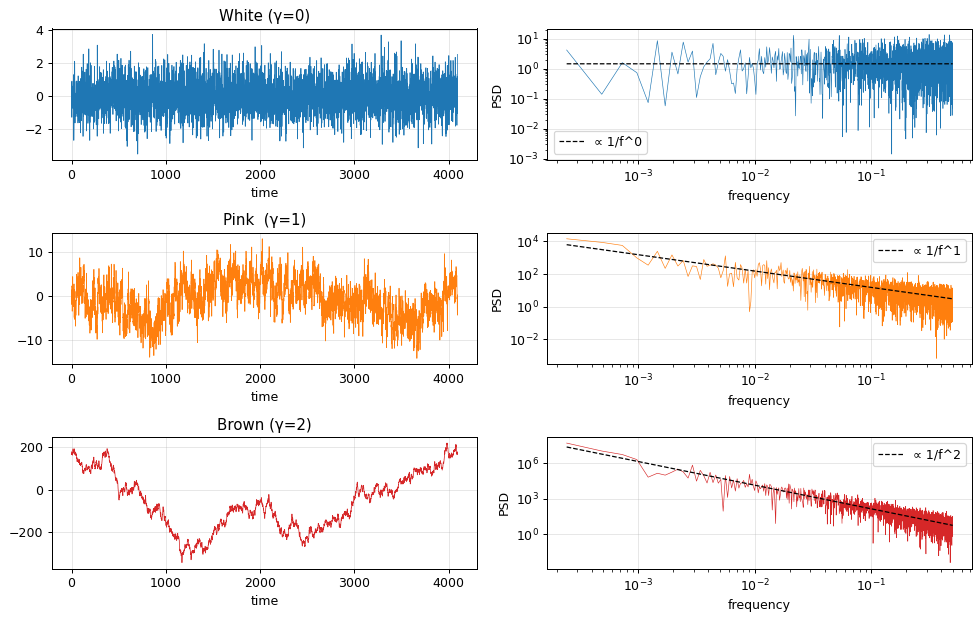

In [6]:
def colored_noise(n, gamma, rng):
    """Return a length-n series with PSD ∝ 1/f^gamma."""
    white = rng.normal(size=n)
    freqs = np.fft.rfftfreq(n, d=1.0)
    freqs[0] = freqs[1]  # avoid divide-by-zero at DC
    filt = freqs ** (-gamma / 2.0)
    spec = np.fft.rfft(white) * filt
    return np.fft.irfft(spec, n)

rng = np.random.default_rng(1)
n = 4096
specs = [(0, 'White (γ=0)', 'C0'),
         (1, 'Pink  (γ=1)', 'C1'),
         (2, 'Brown (γ=2)', 'C3')]

fig, axes = plt.subplots(3, 2, figsize=(11, 7))
for i, (gamma, label, col) in enumerate(specs):
    x = colored_noise(n, gamma, rng)
    axes[i, 0].plot(x, color=col, lw=0.6)
    axes[i, 0].set_title(label); axes[i, 0].set_xlabel('time')
    f, psd = signal.periodogram(x)
    axes[i, 1].loglog(f[1:], psd[1:], color=col, lw=0.5)
    # reference slope line
    ref = f[1:] ** (-gamma)
    ref = ref * np.median(psd[1:100]) / np.median(ref[:100])
    axes[i, 1].loglog(f[1:], ref, 'k--', lw=1, label=f'∝ 1/f^{gamma}')
    axes[i, 1].set_xlabel('frequency'); axes[i, 1].set_ylabel('PSD')
    axes[i, 1].legend()
plt.tight_layout(); plt.show()

## 7. Statistical behaviour — explosive
> 📖 PDF page 18

Variability whose statistics are not stationary because the source undergoes a localized energetic event:

- Magnetic reconnection · Scintillation · Relativistic jets · Microlensing · Supernova · Thermonuclear explosions · Black-hole birth

These are typically modelled with a deterministic template ($g(t, \theta)$) plus stochastic residuals — we will see this decomposition in §26.

## 8. Astronomical data
> 📖 PDF page 19

Three features of real astronomical timeseries that complicate analysis: irregular sampling, heteroscedastic errors, and low signal-to-noise.

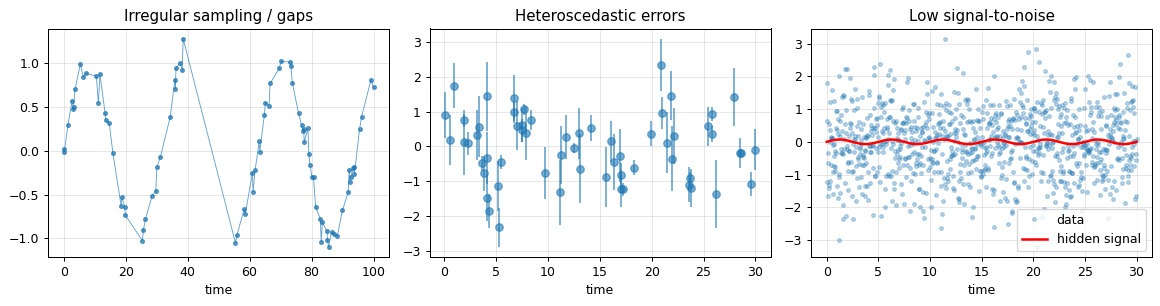

In [7]:
rng = np.random.default_rng(2)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# (a) Irregular sampling / gaps
t = np.linspace(0, 100, 600)
y = np.sin(t/5) + 0.1 * rng.normal(size=t.size)
mask = rng.random(t.size) > 0.85
# simulate a gap
mask[(t > 40) & (t < 55)] = False
axes[0].plot(t[mask], y[mask], '.-', alpha=0.7, lw=0.7)
axes[0].set_title('Irregular sampling / gaps'); axes[0].set_xlabel('time')

# (b) Heteroscedastic errors
n = 60
t = np.sort(rng.uniform(0, 30, n))
sigma = rng.uniform(0.1, 1.0, n)
y = np.sin(t) + sigma * rng.normal(size=n)
axes[1].errorbar(t, y, yerr=sigma, fmt='o', alpha=0.6)
axes[1].set_title('Heteroscedastic errors'); axes[1].set_xlabel('time')

# (c) Low SNR
n = 1000
t = np.linspace(0, 30, n)
true = 0.07 * np.sin(2*np.pi*t/5)
y = true + rng.normal(size=n)
axes[2].plot(t, y, '.', alpha=0.3, label='data')
axes[2].plot(t, true, 'r-', lw=2, label='hidden signal')
axes[2].set_title('Low signal-to-noise'); axes[2].set_xlabel('time')
axes[2].legend()

plt.tight_layout(); plt.show()

## 9. GX 5-1 timeseries
> 📖 PDF page 20

The PDF illustrates the autoregressive workflow on the X-ray binary **GX 5-1** observed by the Ginga satellite. The file `data/GX.dat` contains 65536 = $2^{16}$ photon counts in 1/128 s bins (≈ 512 s total). We reuse this series throughout Part I.

N = 65536 samples (512.0 s of data)
mean = 68.82  std = 10.30  skewness = 0.105  (Gaussian → 0)
sqrt(mean) ≈ Poisson std reference = 8.30  → excess variance over pure Poisson is real


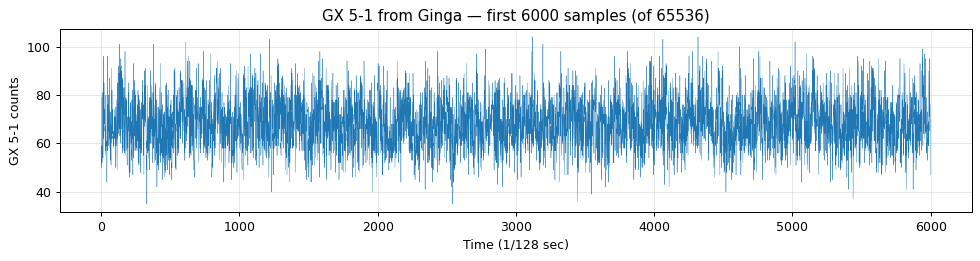

In [8]:
# Load the real Ginga GX 5-1 counts (flatten because the file is laid out 16 per row)
x_gx = np.loadtxt(DATA / 'GX.dat').flatten()
t_gx = np.arange(len(x_gx)) / 128.0  # seconds

print(f'N = {len(x_gx):d} samples ({len(x_gx)/128:.1f} s of data)')
print(f'mean = {x_gx.mean():.2f}  std = {x_gx.std():.2f}  '
      f'skewness = {stats.skew(x_gx):.3f}  (Gaussian → 0)')
print(f'sqrt(mean) ≈ Poisson std reference = {np.sqrt(x_gx.mean()):.2f}  '
      f'→ excess variance over pure Poisson is real')

fig, ax = plt.subplots(figsize=(11, 3))
# show the first ~6000 samples like the slide
n_show = 6000
ax.plot(np.arange(n_show), x_gx[:n_show], lw=0.3)
ax.set_xlabel('Time (1/128 sec)'); ax.set_ylabel('GX 5-1 counts')
ax.set_title(f'GX 5-1 from Ginga — first {n_show} samples (of {len(x_gx)})')
plt.tight_layout(); plt.show()

## 10. Variability modeling overview
> 📖 PDF page 21

| Behaviour | Approach |
|-----------|----------|
| Deterministic trends | Regression |
| **Stochastic / autocorrelated** | **Autoregressive models** ← Part I |
| Periodic | Fourier / harmonic analysis ← Part II |

Most of the classical theory assumes even sampling and homoscedastic errors. Methods for the uneven, heteroscedastic regime of real astronomy are still actively developed (CARMA, IAR, generalized Lomb–Scargle).

## 11. Autocorrelation (ACF)
> 📖 PDF pages 22–23

The autocorrelation function at lag $k$:
$$\mathrm{ACF}(k) = \frac{\sum_{t=1}^{n-k}(x_t - \bar x)(x_{t+k} - \bar x)}{\sum_{t=1}^{n}(x_t - \bar x)^2}$$
We implement the formula by hand and cross-check against `statsmodels.tsa.stattools.acf`. Three diagnostic signatures appear in the correlograms below: white noise (no structure), AR(1) (geometric decay), sine (periodic ACF).

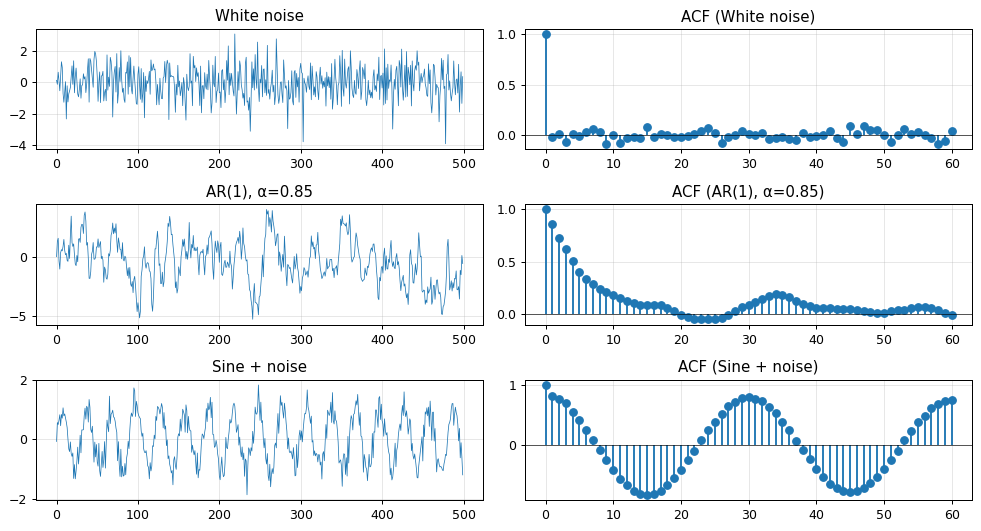

In [9]:
def acf_manual(x, max_lag):
    n = len(x); xbar = x.mean()
    denom = np.sum((x - xbar)**2)
    return np.array([
        np.sum((x[:n-k] - xbar) * (x[k:] - xbar)) / denom
        for k in range(max_lag + 1)
    ])

rng = np.random.default_rng(0)
n = 500
white = rng.normal(size=n)
ar1 = np.zeros(n)
for i in range(1, n):
    ar1[i] = 0.85 * ar1[i-1] + rng.normal()
sine = np.sin(2*np.pi*np.arange(n)/30) + 0.3 * rng.normal(size=n)

procs = [('White noise', white), ('AR(1), α=0.85', ar1), ('Sine + noise', sine)]
max_lag = 60
fig, axes = plt.subplots(3, 2, figsize=(11, 6))
for i, (name, x) in enumerate(procs):
    axes[i, 0].plot(x, lw=0.6); axes[i, 0].set_title(name)
    a_m  = acf_manual(x, max_lag)
    a_sm = acf(x, nlags=max_lag, fft=True)
    np.testing.assert_allclose(a_m, a_sm, atol=1e-8)  # sanity
    axes[i, 1].stem(range(max_lag + 1), a_sm, basefmt=' ')
    axes[i, 1].axhline(0, color='k', lw=0.5)
    axes[i, 1].set_title(f'ACF ({name})')
plt.tight_layout(); plt.show()

## 12. Stationarity
> 📖 PDF page 24

A process is **weakly stationary** if its mean and autocovariance do not depend on time. When autocorrelation is present, the variance of the sample mean grows:
$$\widehat{\mathrm{Var}}(\bar x_n) = \frac{\sigma^2}{n}\left[1 + 2\sum_{k=1}^{n-1}\left(1-\tfrac{k}{n}\right)\mathrm{ACF}(k)\right]$$
Below we verify this Monte-Carlo for white noise (no inflation) and AR(1) with $\alpha = 0.8$ (significant inflation).

In [10]:
def gen_ar1(n, alpha, rng):
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = alpha * x[i-1] + rng.normal()
    return x

n, n_real = 200, 3000
rng = np.random.default_rng(0)

means_w  = np.array([rng.normal(size=n).mean() for _ in range(n_real)])
means_ar = np.array([gen_ar1(n, 0.8, rng).mean() for _ in range(n_real)])

# Theory
sigma2_ar = 1.0 / (1 - 0.8**2)  # stationary variance of AR(1) with σ_ε=1
k = np.arange(1, n)
acf_ar = 0.8 ** np.arange(n)
theory_ar = (sigma2_ar / n) * (1 + 2 * np.sum((1 - k/n) * acf_ar[1:n]))

print(f"White noise:    Var(mean) empirical = {means_w.var():.5f},  theory σ²/n = {1/n:.5f}")
print(f"AR(1), α=0.8:   Var(mean) empirical = {means_ar.var():.4f},  theory = {theory_ar:.4f}")
print(f"Inflation factor vs. white noise:    {means_ar.var() / (sigma2_ar/n):.2f}×")

White noise:    Var(mean) empirical = 0.00498,  theory σ²/n = 0.00500
AR(1), α=0.8:   Var(mean) empirical = 0.1203,  theory = 0.1222
Inflation factor vs. white noise:    8.67×


## 13. Histogram of GX 5-1
> 📖 PDF page 25

A pure white-noise model predicts a Gaussian intensity distribution. The histogram of the GX 5-1 counts shows excess variance and a small positive skew — a first hint that white noise alone is inadequate.

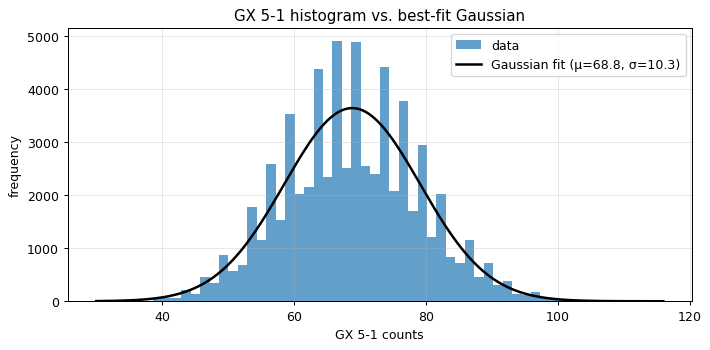

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
counts, bins, _ = ax.hist(x_gx, bins=60, alpha=0.7, density=False, label='data')
# best-fit Gaussian
mu, sigma = x_gx.mean(), x_gx.std()
xv = np.linspace(bins[0], bins[-1], 300)
binwidth = bins[1] - bins[0]
ax.plot(xv, len(x_gx) * binwidth * stats.norm.pdf(xv, mu, sigma),
        'k-', lw=2, label=f'Gaussian fit (μ={mu:.1f}, σ={sigma:.1f})')
ax.set_xlabel('GX 5-1 counts'); ax.set_ylabel('frequency')
ax.set_title('GX 5-1 histogram vs. best-fit Gaussian'); ax.legend()
plt.tight_layout(); plt.show()

## 14. Smoothing — CMA and EWMA
> 📖 PDF pages 26–27

Two simple smoothers used for visual exploration:
- **Central moving average (CMA)**: $\hat X_{i, \text{CMA}}(j) = \frac{1}{j+1}\sum_{k=-j/2}^{j/2} X_{i+k}$
- **Exponentially weighted moving average (EWMA)**: $\hat X_{i, \text{EWMA}} = \alpha X_i + (1-\alpha)\hat X_{i-1, \text{EWMA}}$

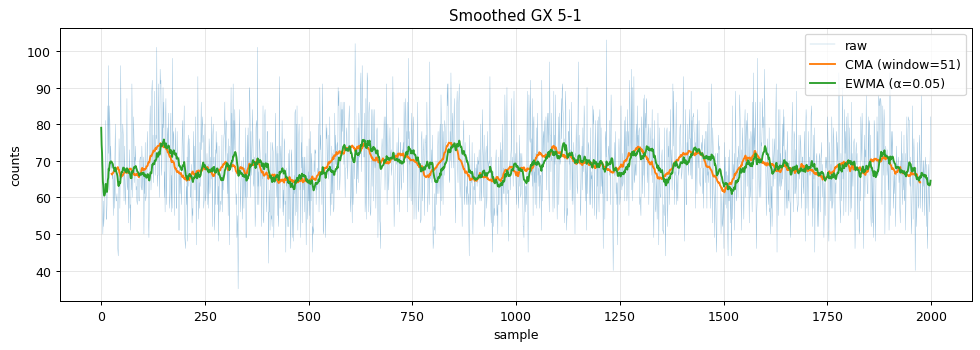

In [12]:
# Subsample so the plot is legible
s = pd.Series(x_gx[:2000])
cma  = s.rolling(window=51, center=True).mean()
ewma = s.ewm(alpha=0.05).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s, lw=0.3, alpha=0.5, label='raw')
ax.plot(cma,  lw=1.5, label='CMA (window=51)')
ax.plot(ewma, lw=1.5, label='EWMA (α=0.05)')
ax.set_xlabel('sample'); ax.set_ylabel('counts')
ax.set_title('Smoothed GX 5-1'); ax.legend()
plt.tight_layout(); plt.show()

## 15. Partial autocorrelation function (PACF)
> 📖 PDF pages 28–29

PACF gives the correlation at lag $k$ **after removing** correlations at shorter lags. It is useful for diagnosing AR order: for a true AR($p$) process, PACF cuts off at lag $p$.

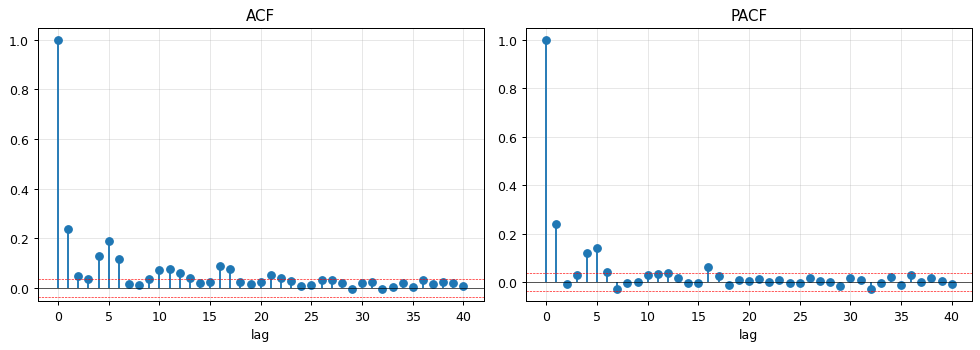

In [13]:
# Use a shorter slice for speed
x_short = x_gx[:3000]
max_lag = 40

a  = acf(x_short,  nlags=max_lag, fft=True)
pa = pacf(x_short, nlags=max_lag)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].stem(range(max_lag+1), a,  basefmt=' '); axes[0].set_title('ACF')
axes[1].stem(range(max_lag+1), pa, basefmt=' '); axes[1].set_title('PACF')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline( 1.96/np.sqrt(len(x_short)), color='r', ls='--', lw=0.5)
    ax.axhline(-1.96/np.sqrt(len(x_short)), color='r', ls='--', lw=0.5)
    ax.set_xlabel('lag')
plt.tight_layout(); plt.show()

## 16. Lag-k scatter plot
> 📖 PDF page 30

Plot $x_{t+k}$ vs $x_t$ to visualise the autocorrelation structure:
- **No structure** → uncorrelated noise · **Linear** → AR · **Loop/ellipse** → periodic · **Clusters** → non-stationary

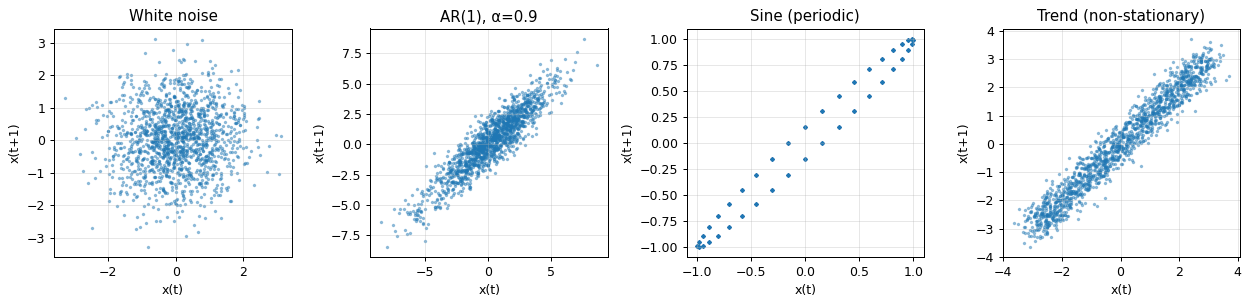

In [14]:
def lag_scatter(ax, x, k, title):
    ax.scatter(x[:-k], x[k:], s=3, alpha=0.4)
    ax.set_xlabel(f'x(t)'); ax.set_ylabel(f'x(t+{k})')
    ax.set_title(title)

rng = np.random.default_rng(5)
n = 1500
white  = rng.normal(size=n)
ar1_   = gen_ar1(n, 0.9, rng)
sine   = np.sin(2*np.pi*np.arange(n)/40)
trend  = np.linspace(-3, 3, n) + 0.3 * rng.normal(size=n)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
lag_scatter(axes[0], white, 1, 'White noise')
lag_scatter(axes[1], ar1_,  1, 'AR(1), α=0.9')
lag_scatter(axes[2], sine,  1, 'Sine (periodic)')
lag_scatter(axes[3], trend, 1, 'Trend (non-stationary)')
plt.tight_layout(); plt.show()

## 17. Durbin–Watson statistic
> 📖 PDF page 31

$$d_{DW} = \frac{\sum_{i=2}^{n}(x_i - x_{i-1})^2}{\sum_{i=1}^{n} x_i^2}$$
- $d_{DW} \approx 2$ → no autocorrelation
- $d_{DW} < 2$ → positive autocorrelation
- $d_{DW} > 2$ → negative autocorrelation

In [15]:
rng = np.random.default_rng(7)
n = 1000
cases = {
    'White noise':              rng.normal(size=n),
    'AR(1), α = +0.85':         gen_ar1(n, 0.85, rng),
    'AR(1), α = -0.85':         gen_ar1(n, -0.85, rng),
    'Random walk (α=1)':        np.cumsum(rng.normal(size=n)),
}

rows = []
for name, x in cases.items():
    # Manual:
    dw_manual = np.sum(np.diff(x)**2) / np.sum(x**2)
    # statsmodels (expects regression residuals; we feed the deviation from the mean)
    dw_sm = durbin_watson(x - x.mean())
    rows.append((name, dw_manual, dw_sm))

pd.DataFrame(rows, columns=['process', 'DW (manual)', 'DW (statsmodels)'])

,process,DW (manual),DW (statsmodels)
0,White noise,1.923060,1.934398
1,"AR(1), α = +0.85",0.264328,0.264413
2,"AR(1), α = -0.85",3.709949,3.709979
3,Random walk (α=1),0.002245,0.010505


## 18. Random walk
> 📖 PDF page 32

Simplest autocorrelated process: $X_i = X_{i-1} + \varepsilon_i$ with $X_0 = 0$, so $X_i = \sum_{j=1}^{i}\varepsilon_j$.

**Important subtlety.** The random walk is **non-stationary**: $\mathrm{Var}(X_i) = i\sigma^2$ grows with time. So:

- The *time-dependent* autocorrelation $\mathrm{Corr}(X_i, X_{i+k})$ is well-defined and equals
  $$\rho(i, i+k) = \frac{\mathrm{Cov}(X_i, X_{i+k})}{\sqrt{\mathrm{Var}(X_i)\,\mathrm{Var}(X_{i+k})}} = \frac{i}{\sqrt{i\,(i+k)}} = \frac{1}{\sqrt{1 + k/i}}.$$
  (The slide formula $1/(1 + k/i)$ corresponds to a different normalization, $\mathrm{Cov}/\mathrm{Var}(X_{i+k})$, and underestimates the correlation.)

- The **standard sample ACF estimator** (e.g. `statsmodels.tsa.stattools.acf`) *assumes stationarity* — it averages $(x_t - \bar x)(x_{t+k} - \bar x)$ over all $t$ and divides by the sample variance. Applied to a non-stationary random walk, that estimator does **not** measure $\rho(i, i+k)$ for any single $i$; it is sample-dependent and can even go negative for large $k$.

We verify both points below.

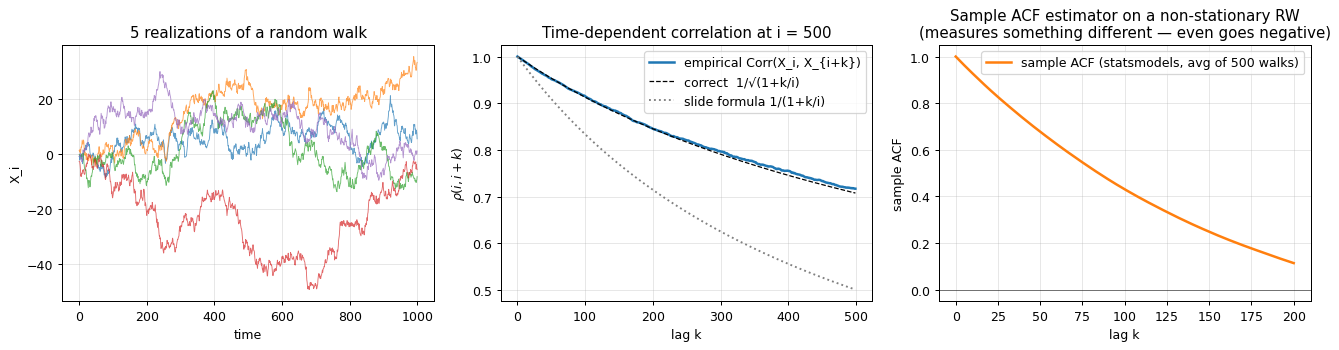

In [16]:
rng = np.random.default_rng(9)
n_real, n = 5, 1000
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Five realizations
for _ in range(n_real):
    rw = np.cumsum(rng.normal(size=n))
    axes[0].plot(rw, lw=0.7, alpha=0.7)
axes[0].set_title('5 realizations of a random walk')
axes[0].set_xlabel('time'); axes[0].set_ylabel('X_i')

# (b) Time-dependent ρ(i, i+k) estimated by ensemble averaging
# For each fixed i, average X_i · X_{i+k} across many realizations.
n_walks = 2000
walks = np.cumsum(rng.normal(size=(n_walks, n)), axis=1)
i_fixed = n // 2     # pick i = 500
k_arr   = np.arange(0, n - i_fixed)
Xi   = walks[:, i_fixed]
emp_rho = np.array([np.corrcoef(Xi, walks[:, i_fixed + k])[0, 1] for k in k_arr])
theory  = 1 / np.sqrt(1 + k_arr / i_fixed)
slide   = 1 / (1 + k_arr / i_fixed)

axes[1].plot(k_arr, emp_rho, 'C0-', lw=2, label='empirical Corr(X_i, X_{i+k})')
axes[1].plot(k_arr, theory, 'k--', lw=1, label='correct  1/√(1+k/i)')
axes[1].plot(k_arr, slide, ':', color='gray', label='slide formula 1/(1+k/i)')
axes[1].set_xlabel('lag k'); axes[1].set_ylabel(r'$\rho(i, i+k)$')
axes[1].set_title(f'Time-dependent correlation at i = {i_fixed}')
axes[1].legend()

# (c) What the stationarity-assuming sample ACF actually computes
max_lag = 200
sample_acf = np.zeros(max_lag + 1)
for w in walks[:500]:
    sample_acf += acf(w, nlags=max_lag, fft=True)
sample_acf /= 500
axes[2].plot(np.arange(max_lag + 1), sample_acf, 'C1-', lw=2,
             label='sample ACF (statsmodels, avg of 500 walks)')
axes[2].axhline(0, color='k', lw=0.4)
axes[2].set_xlabel('lag k'); axes[2].set_ylabel('sample ACF')
axes[2].set_title('Sample ACF estimator on a non-stationary RW\n(measures something different — even goes negative)')
axes[2].legend()
plt.tight_layout(); plt.show()

## 19. Autoregressive AR(p) models
> 📖 PDF pages 33–36

$$X_i = \sum_{j=1}^{p} \alpha_j X_{i-j} + \varepsilon_i, \quad \varepsilon_i \sim N(0, \sigma^2)$$
For AR(1) the ACF is $\alpha_1^k$ — geometric decay if $|\alpha_1| < 1$.

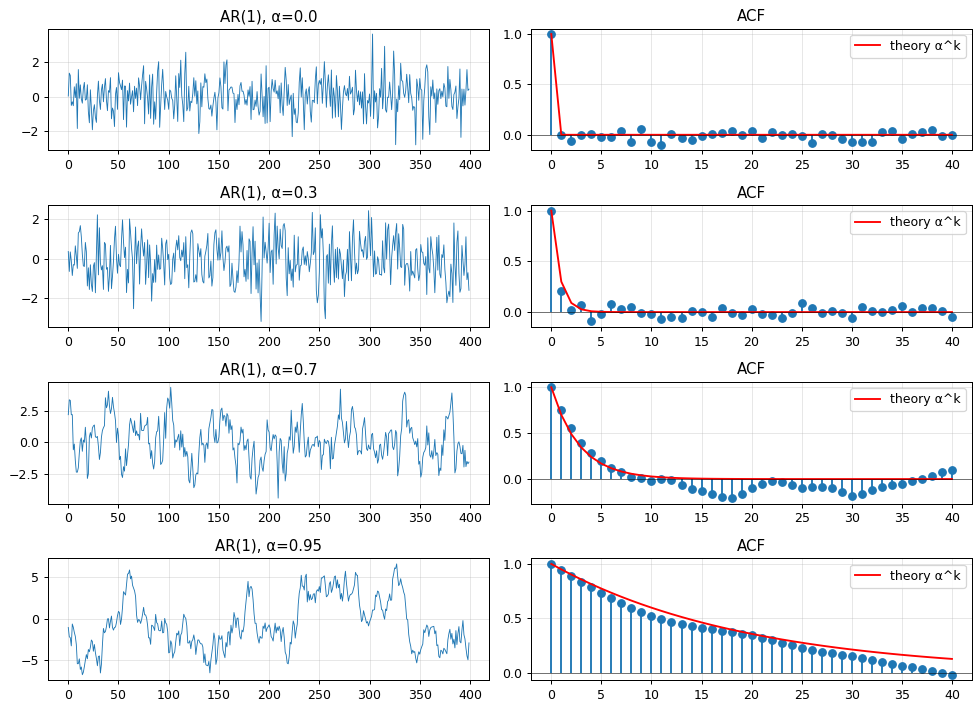

In [17]:
rng = np.random.default_rng(11)
n = 400
alphas = [0.0, 0.3, 0.7, 0.95]

fig, axes = plt.subplots(len(alphas), 2, figsize=(11, 8))
for i, a in enumerate(alphas):
    ar = ArmaProcess(ar=np.array([1, -a]), ma=np.array([1]))
    x  = ar.generate_sample(n, distrvs=rng.normal)
    axes[i, 0].plot(x, lw=0.7); axes[i, 0].set_title(f'AR(1), α={a}')
    a_emp = acf(x, nlags=40, fft=True)
    axes[i, 1].stem(range(41), a_emp, basefmt=' ')
    axes[i, 1].plot(range(41), a ** np.arange(41), 'r-', label='theory α^k')
    axes[i, 1].set_title('ACF'); axes[i, 1].legend()
    axes[i, 1].axhline(0, color='k', lw=0.4)
plt.tight_layout(); plt.show()

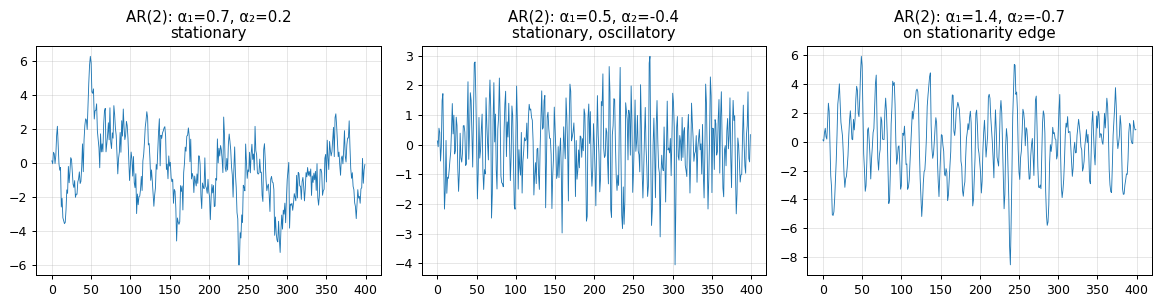

In [18]:
# AR(2) — explore the stationarity triangle
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
configs = [(0.7, 0.2, 'stationary'),
           (0.5, -0.4, 'stationary, oscillatory'),
           (1.4, -0.7, 'on stationarity edge')]
for ax, (a1, a2, label) in zip(axes, configs):
    ar = ArmaProcess(ar=np.array([1, -a1, -a2]), ma=np.array([1]))
    x  = ar.generate_sample(400, distrvs=np.random.default_rng(0).normal)
    ax.plot(x, lw=0.7)
    ax.set_title(f'AR(2): α₁={a1}, α₂={a2}\n{label}')
plt.tight_layout(); plt.show()

## 20. Moving-average MA(q) models
> 📖 PDF pages 37–38

$$X_i = \varepsilon_i + \beta_1 \varepsilon_{i-1} + \dots + \beta_q \varepsilon_{i-q}$$
MA models have *finite memory* — the ACF cuts off at lag $q$.

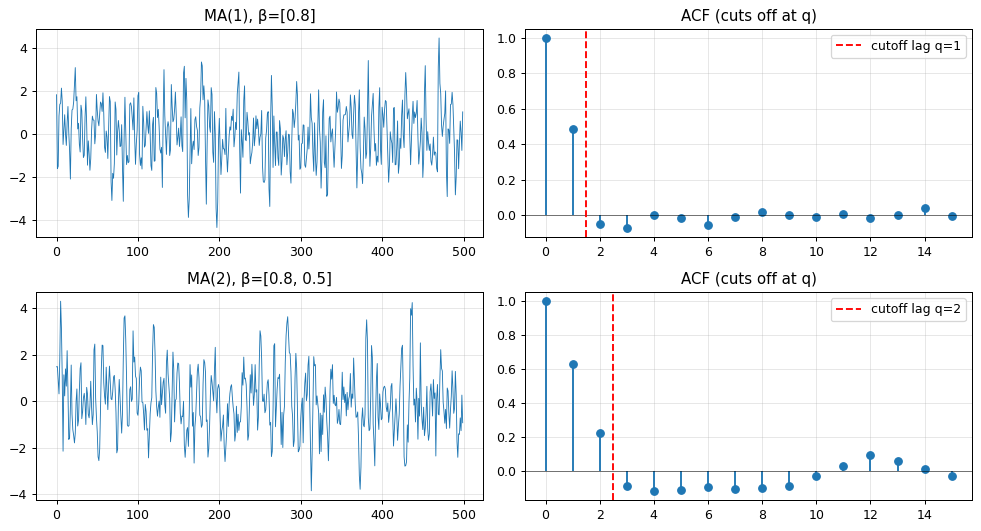

In [19]:
rng = np.random.default_rng(13)
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for i, (q, betas) in enumerate([(1, [0.8]), (2, [0.8, 0.5])]):
    ma = ArmaProcess(ar=np.array([1]), ma=np.array([1] + betas))
    x  = ma.generate_sample(500, distrvs=rng.normal)
    axes[i, 0].plot(x, lw=0.7); axes[i, 0].set_title(f'MA({q}), β={betas}')
    a_emp = acf(x, nlags=15, fft=True)
    axes[i, 1].stem(range(16), a_emp, basefmt=' ')
    axes[i, 1].axhline(0, color='k', lw=0.4)
    axes[i, 1].axvline(q + 0.5, color='r', ls='--', label=f'cutoff lag q={q}')
    axes[i, 1].set_title('ACF (cuts off at q)'); axes[i, 1].legend()
plt.tight_layout(); plt.show()

## 21. ARMA(p, q) models
> 📖 PDF page 39

Combines both: $p$ autoregressive terms and $q$ moving-average terms.
We simulate an ARMA(2, 1), fit it with `statsmodels`, and check the residuals are white.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.055      0.007      0.994      -0.107       0.107
ar.L1          0.5826      0.045     12.897      0.000       0.494       0.671
ar.L2         -0.1744      0.037     -4.756      0.000      -0.246      -0.103
ma.L1          0.4221      0.043      9.922      0.000       0.339       0.505
sigma2         1.0247      0.032     31.869      0.000       0.962       1.088


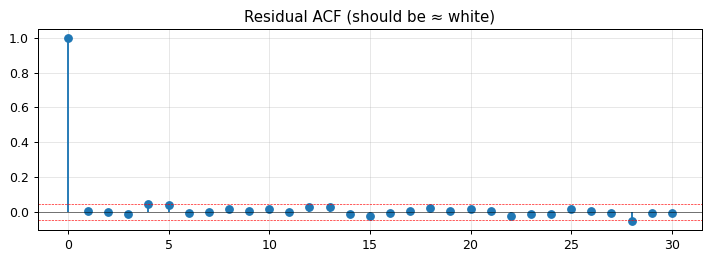

In [20]:
rng = np.random.default_rng(17)
true_ar = [1, -0.6, 0.2]       # 1 - 0.6 z + 0.2 z² (in lag-polynomial form)
true_ma = [1, 0.4]

ap = ArmaProcess(ar=true_ar, ma=true_ma)
x = ap.generate_sample(2000, distrvs=rng.normal)

model = ARIMA(x, order=(2, 0, 1)).fit()
print(model.summary().tables[1])

# Residual ACF should be flat
fig, ax = plt.subplots(figsize=(8, 3))
res_acf = acf(model.resid, nlags=30, fft=True)
ax.stem(range(31), res_acf, basefmt=' ')
ax.axhline(0, color='k', lw=0.4)
ax.axhline( 1.96/np.sqrt(len(x)), color='r', ls='--', lw=0.5)
ax.axhline(-1.96/np.sqrt(len(x)), color='r', ls='--', lw=0.5)
ax.set_title('Residual ACF (should be ≈ white)')
plt.tight_layout(); plt.show()

## 22. Periodogram of GX 5-1
> 📖 PDF pages 40–42

The raw periodogram is noisy; smoothing (here with a Daniell-style boxcar) makes the QPO peak near $f \approx 0.19$ visible. An AR($p$) spectral density fitted to the data picks up the same feature.

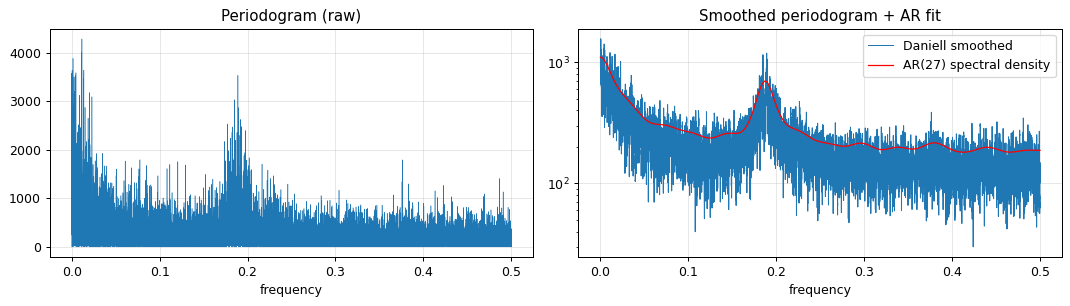

In [21]:
f, psd = signal.periodogram(x_gx)
# Daniell smoother
win = np.ones(11) / 11
psd_smooth = np.convolve(psd, win, mode='same')

# AR(p) spectral density
p = 27
ar_fit = sm.tsa.AutoReg(x_gx, lags=p, old_names=False).fit()
ar_coefs = np.r_[1, -ar_fit.params[1:]]    # 1 - α1 z - α2 z² - ...
sigma2   = ar_fit.sigma2
w = 2*np.pi*f
ar_psd = sigma2 / np.abs(np.polyval(ar_coefs[::-1], np.exp(-1j*w)))**2
# rescale so they overlap visually
ar_psd *= psd_smooth[5:50].mean() / ar_psd[5:50].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(f, psd, lw=0.4)
axes[0].set_title('Periodogram (raw)'); axes[0].set_xlabel('frequency')
axes[1].plot(f, psd_smooth, lw=0.8, label='Daniell smoothed')
axes[1].plot(f, ar_psd, 'r-', lw=1, label=f'AR({p}) spectral density')
axes[1].set_yscale('log')
axes[1].set_title('Smoothed periodogram + AR fit')
axes[1].set_xlabel('frequency'); axes[1].legend()
plt.tight_layout(); plt.show()

## 23. AIC and BIC for AR-order selection
> 📖 PDF pages 43–45

$$\mathrm{AIC}(p) = N\ln(\hat\sigma^2) + 2p, \qquad \mathrm{BIC}(p) = N\ln(\hat\sigma^2) + \ln(N)\, p$$
BIC penalizes complexity more harshly. We sweep AR orders 0–30 and pick the argmin.

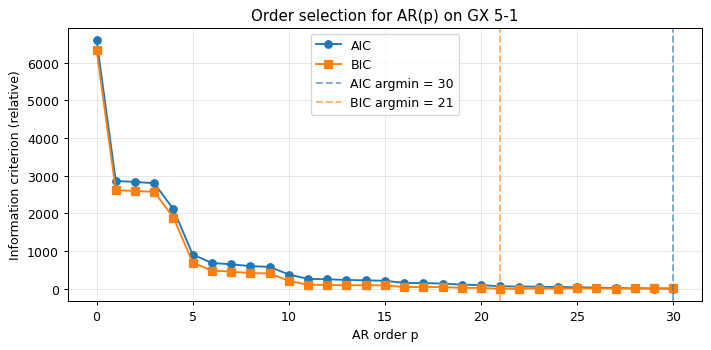

In [22]:
orders = range(0, 31)
aics, bics = [], []
for p in orders:
    if p == 0:
        # Just the variance of x as the "model"
        sigma2 = x_gx.var()
        n = len(x_gx)
        ll = -0.5 * n * (np.log(2*np.pi*sigma2) + 1)
        aics.append(-2*ll + 2*p); bics.append(-2*ll + np.log(n)*p)
        continue
    m = sm.tsa.AutoReg(x_gx, lags=p, old_names=False).fit()
    aics.append(m.aic); bics.append(m.bic)

aics = np.array(aics); bics = np.array(bics)
p_aic = orders[int(np.argmin(aics))]
p_bic = orders[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(orders, aics - aics.min(), 'o-', label='AIC')
ax.plot(orders, bics - bics.min(), 's-', label='BIC')
ax.axvline(p_aic, color='C0', ls='--', alpha=0.6, label=f'AIC argmin = {p_aic}')
ax.axvline(p_bic, color='C1', ls='--', alpha=0.6, label=f'BIC argmin = {p_bic}')
ax.set_xlabel('AR order p'); ax.set_ylabel('Information criterion (relative)')
ax.set_title('Order selection for AR(p) on GX 5-1'); ax.legend()
plt.tight_layout(); plt.show()

## 24. ARIMA / ARCH / GARCH
> 📖 PDF page 46

- **ARIMA(p, d, q)** — ARMA on the $d$-times differenced series; handles unit-root non-stationarity.
- **ARCH/GARCH** — model time-varying *variance* (volatility clustering).

Below: ARIMA(1, 1, 1) on a random-walk-plus-drift; hand-simulated ARCH(1) shows volatility clustering.

ARIMA(1,1,1) params: {'ar.L1': np.float64(-0.39), 'ma.L1': np.float64(0.383), 'sigma2': np.float64(0.94)}


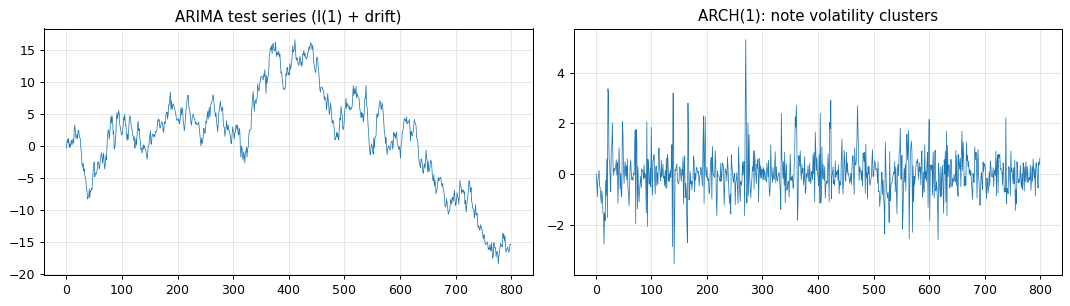

In [23]:
rng = np.random.default_rng(19)

# (a) ARIMA on a unit-root series
n = 800
drift = 0.02
y = np.cumsum(drift + rng.normal(size=n))  # I(1) with drift
arima_fit = ARIMA(y, order=(1, 1, 1)).fit()
print('ARIMA(1,1,1) params:', dict(zip(arima_fit.param_names, arima_fit.params.round(3))))

# (b) ARCH(1): σ_t² = ω + α·x_{t-1}²
omega, alpha = 0.2, 0.85
x = np.zeros(n)
sig2 = np.zeros(n); sig2[0] = omega / (1 - alpha)
for i in range(1, n):
    sig2[i] = omega + alpha * x[i-1]**2
    x[i] = np.sqrt(sig2[i]) * rng.normal()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(y, lw=0.6); axes[0].set_title('ARIMA test series (I(1) + drift)')
axes[1].plot(x, lw=0.6); axes[1].set_title('ARCH(1): note volatility clusters')
plt.tight_layout(); plt.show()

## 25. Irregular sampling — CARMA and IAR
> 📖 PDF pages 47–48

For irregularly sampled data, the IAR model (Eyheramendy+2018) generalizes AR(1) to arbitrary $\Delta t_j$:
$$y_{t_j} = \phi^{\Delta t_j}\, y_{t_{j-1}} + \sigma\sqrt{1 - \phi^{2\Delta t_j}}\, \varepsilon_{t_j}$$
We simulate from this model and recover $\phi$ by maximum likelihood on a grid.

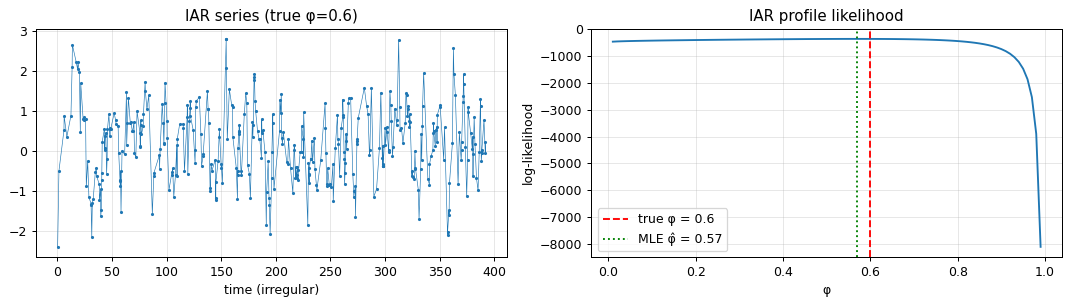

In [24]:
def iar_simulate(t, phi, sigma, rng):
    y = np.zeros_like(t)
    y[0] = rng.normal(0, sigma)
    for j in range(1, len(t)):
        dt = t[j] - t[j-1]
        y[j] = (phi ** dt) * y[j-1] + sigma * np.sqrt(1 - phi**(2*dt)) * rng.normal()
    return y

def iar_loglik(phi, t, y, sigma):
    if not (0 < phi < 1): return -np.inf
    dt = np.diff(t)
    mu = (phi ** dt) * y[:-1]
    var = sigma**2 * (1 - phi**(2*dt))
    return float(-0.5 * np.sum(np.log(2*np.pi*var) + (y[1:] - mu)**2 / var))

rng = np.random.default_rng(21)
n = 400
# irregular sampling: exponentially distributed gaps
t = np.cumsum(rng.exponential(scale=1.0, size=n))
true_phi, true_sigma = 0.6, 1.0
y = iar_simulate(t, true_phi, true_sigma, rng)

phi_grid = np.linspace(0.01, 0.99, 99)
ll = [iar_loglik(p, t, y, true_sigma) for p in phi_grid]
phi_hat = phi_grid[int(np.argmax(ll))]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(t, y, '.-', lw=0.5, ms=3)
axes[0].set_title(f'IAR series (true φ={true_phi})')
axes[0].set_xlabel('time (irregular)')
axes[1].plot(phi_grid, ll)
axes[1].axvline(true_phi, color='r', ls='--', label=f'true φ = {true_phi}')
axes[1].axvline(phi_hat,  color='g', ls=':',  label=f'MLE φ̂ = {phi_hat:.2f}')
axes[1].set_xlabel('φ'); axes[1].set_ylabel('log-likelihood'); axes[1].legend()
axes[1].set_title('IAR profile likelihood')
plt.tight_layout(); plt.show()

## 26. Application — $z_t = g(t,\theta) + \delta_t$
> 📖 PDF page 48

End-to-end recipe: subtract a deterministic model, then model the residuals as an autoregressive process.

Residual AR(1) coefficient: 0.620 (true was 0.6)


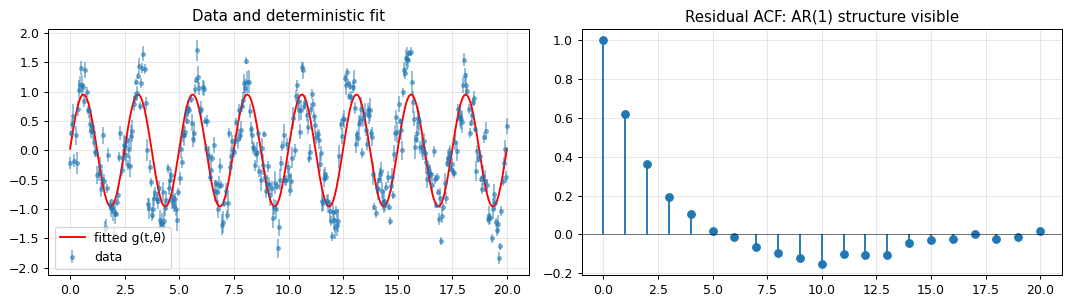

In [25]:
rng = np.random.default_rng(23)
n = 400
t = np.linspace(0, 20, n)
# True signal
P_true = 2.5
g_true = 1.0 * np.sin(2*np.pi*t/P_true)
# AR(1) residual + heteroscedastic noise
res = gen_ar1(n, 0.6, rng) * 0.3
sigma = rng.uniform(0.05, 0.2, n)
z = g_true + res + sigma * rng.normal(size=n)

# Step 1: fit g(t, θ) — here, weighted least-squares sinusoid at known P
A = np.column_stack([np.sin(2*np.pi*t/P_true), np.cos(2*np.pi*t/P_true), np.ones(n)])
W = np.diag(1 / sigma**2)
theta = np.linalg.solve(A.T @ W @ A, A.T @ W @ z)
g_hat = A @ theta

# Step 2: residual ACF and AR(1) fit
delta = z - g_hat
ar_res = sm.tsa.AutoReg(delta, lags=1, old_names=False).fit()
print(f"Residual AR(1) coefficient: {ar_res.params[1]:.3f} (true was 0.6)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].errorbar(t, z, yerr=sigma, fmt='.', alpha=0.5, label='data')
axes[0].plot(t, g_hat, 'r-', label='fitted g(t,θ)')
axes[0].set_title('Data and deterministic fit'); axes[0].legend()
axes[1].stem(range(21), acf(delta, nlags=20, fft=True), basefmt=' ')
axes[1].axhline(0, color='k', lw=0.4)
axes[1].set_title('Residual ACF: AR(1) structure visible')
plt.tight_layout(); plt.show()

---
# Part II — Fourier analysis & period finding
*PDF pages 51–87*

## 27. Periodic variability — HR diagram context
> 📖 PDF pages 52–56

Many variability classes occupy specific regions of the Hertzsprung–Russell diagram:
- **Cepheids** (instability strip, supergiants) — periods of days
- **RR Lyrae** (horizontal branch, intermediate temperature) — periods of hours
- **Long-period variables** (cool giants) — periods of months to years

The **period–luminosity relation** for Cepheids and RR Lyrae is one of the foundations of the cosmic distance ladder. We illustrate the sense of the relation with toy data.

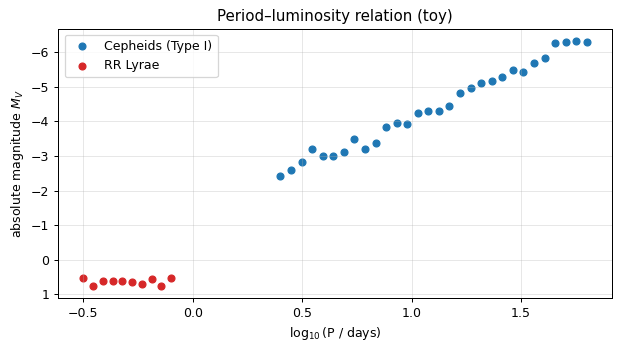

In [26]:
rng = np.random.default_rng(25)
# Toy Cepheid P-L relation: M_V = -2.78 log P - 1.35 (Type I)
logP = np.linspace(0.4, 1.8, 30)
M_ceph = -2.78 * logP - 1.35 + 0.15 * rng.normal(size=logP.size)
# RR Lyrae are nearly constant at M_V ≈ +0.6, log P ≈ -0.4 to -0.1
logP_rr = np.linspace(-0.5, -0.1, 10)
M_rr = 0.6 + 0.1 * rng.normal(size=logP_rr.size)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(logP,    M_ceph, s=30, label='Cepheids (Type I)')
ax.scatter(logP_rr, M_rr,   s=30, color='C3', label='RR Lyrae')
ax.set_xlabel(r'$\log_{10}$(P / days)')
ax.set_ylabel(r'absolute magnitude $M_V$')
ax.invert_yaxis()
ax.set_title('Period–luminosity relation (toy)')
ax.legend()
plt.tight_layout(); plt.show()

## 28. Fourier transform
> 📖 PDF page 57

$$H(f) = \int_{-\infty}^{\infty} h(t)\,e^{-i 2\pi f t}\,dt, \qquad h(t) = \int_{-\infty}^{\infty} H(f)\,e^{i 2\pi f t}\,df$$

We numerically verify the analytical FT of a Gaussian: $h(t) = e^{-t^2/2\sigma^2} \Rightarrow H(f) = \sigma\sqrt{2\pi}\, e^{-2\pi^2 \sigma^2 f^2}$.

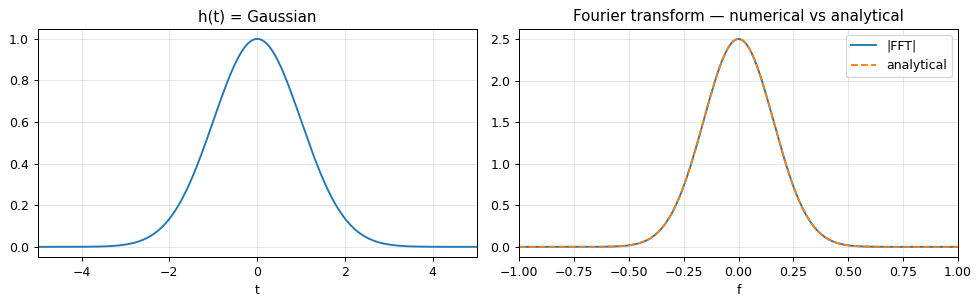

In [27]:
sigma_t = 1.0
N = 4096
dt = 0.02
t = (np.arange(N) - N/2) * dt
h = np.exp(-t**2 / (2 * sigma_t**2))

H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h))) * dt  # continuous-FT estimate
f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
H_theory = sigma_t * np.sqrt(2*np.pi) * np.exp(-2*np.pi**2 * sigma_t**2 * f**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t, h); axes[0].set_xlim(-5, 5)
axes[0].set_title('h(t) = Gaussian'); axes[0].set_xlabel('t')
axes[1].plot(f, np.real(H),    label='|FFT|')
axes[1].plot(f, H_theory, '--', label='analytical')
axes[1].set_xlim(-1, 1); axes[1].set_xlabel('f'); axes[1].legend()
axes[1].set_title('Fourier transform — numerical vs analytical')
plt.tight_layout(); plt.show()

## 29. FT properties — translation and PSD of a sine
> 📖 PDF page 58

- **Translation**: $h(t + \Delta t) \leftrightarrow H(f)\, e^{i 2\pi f \Delta t}$ — only the phase changes.
- **PSD of a pure sine**: $\sin(2\pi t/T) \Rightarrow$ delta function at $f = 1/T$ in the PSD.

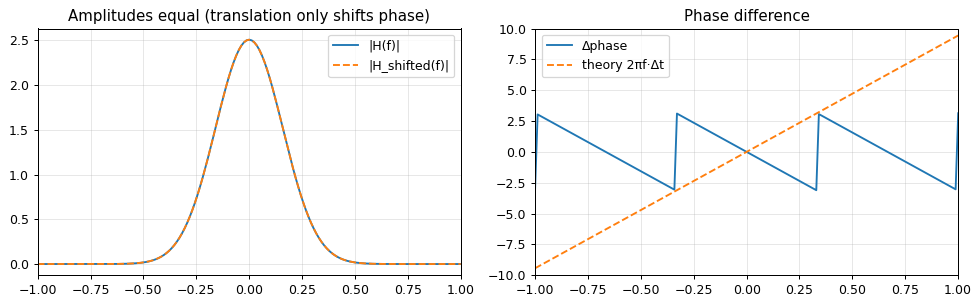

In [28]:
# Translation property
shift = 1.5
h_shifted = np.exp(-(t - shift)**2 / (2*sigma_t**2))
H_shifted = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_shifted))) * dt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(f, np.abs(H), label='|H(f)|')
axes[0].plot(f, np.abs(H_shifted), '--', label='|H_shifted(f)|')
axes[0].set_xlim(-1, 1); axes[0].set_title('Amplitudes equal (translation only shifts phase)')
axes[0].legend()
axes[1].plot(f, np.angle(H_shifted) - np.angle(H), label='Δphase')
axes[1].plot(f, 2*np.pi*f*shift, '--', label='theory 2πf·Δt')
axes[1].set_xlim(-1, 1); axes[1].set_ylim(-10, 10); axes[1].legend()
axes[1].set_title('Phase difference')
plt.tight_layout(); plt.show()

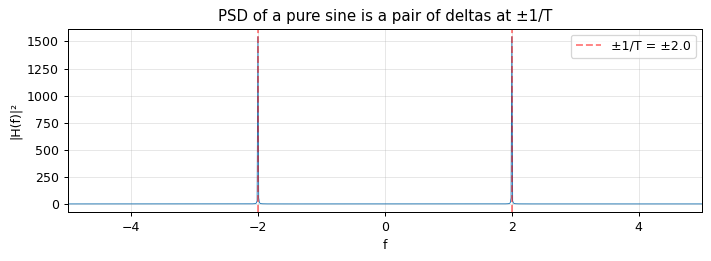

In [29]:
# PSD of a pure sine
T_per = 0.5
sine = np.sin(2*np.pi*t / T_per)
H_sine = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sine))) * dt
psd_sine = np.abs(H_sine)**2

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(f, psd_sine, lw=0.7)
ax.axvline( 1/T_per, color='r', ls='--', alpha=0.5, label=f'±1/T = ±{1/T_per}')
ax.axvline(-1/T_per, color='r', ls='--', alpha=0.5)
ax.set_xlim(-5, 5); ax.set_xlabel('f'); ax.set_ylabel('|H(f)|²')
ax.set_title('PSD of a pure sine is a pair of deltas at ±1/T'); ax.legend()
plt.tight_layout(); plt.show()

## 30. Parseval and convolution theorems
> 📖 PDF pages 59–60

- **Parseval**: total power is conserved between domains.  $\int |h(t)|^2\,dt = \int |H(f)|^2\,df$
- **Convolution theorem**: convolution in time ↔ multiplication in frequency.

∫|h(t)|² dt = 1.7725
∫|H(f)|² df = 1.7725
ratio: 1.000000


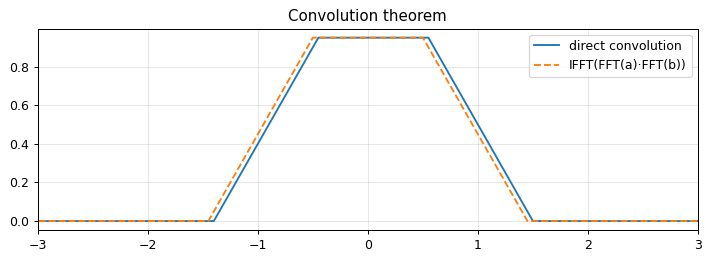

In [30]:
# Parseval check
power_time = np.sum(np.abs(h)**2) * dt
power_freq = np.sum(np.abs(H)**2) * (f[1] - f[0])
print(f"∫|h(t)|² dt = {power_time:.4f}")
print(f"∫|H(f)|² df = {power_freq:.4f}")
print(f"ratio: {power_time / power_freq:.6f}")

# Convolution theorem: convolve two boxes
N = 512; dt = 0.05
t = (np.arange(N) - N/2) * dt
a = (np.abs(t) < 1.0).astype(float)
b = (np.abs(t) < 0.5).astype(float)
conv_direct = np.convolve(a, b, mode='same') * dt

A = np.fft.fft(np.fft.ifftshift(a))
B = np.fft.fft(np.fft.ifftshift(b))
conv_fft = np.fft.fftshift(np.real(np.fft.ifft(A * B))) * dt

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, conv_direct, label='direct convolution')
ax.plot(t, conv_fft, '--', label='IFFT(FFT(a)·FFT(b))')
ax.set_xlim(-3, 3); ax.set_title('Convolution theorem'); ax.legend()
plt.tight_layout(); plt.show()

## 31. Discrete Fourier transform
> 📖 PDF page 61

$$H_k = \sum_{j=0}^{N-1} h_j\, e^{-i 2\pi j k / N}, \qquad h_j = \frac{1}{N}\sum_{k=0}^{N-1} H_k\, e^{i 2\pi j k / N}$$
We implement the DFT as a matrix multiply (O(N²)) and verify against `numpy.fft`.

In [31]:
def dft_matrix(N):
    j, k = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')
    return np.exp(-1j * 2 * np.pi * j * k / N)

N = 64
h = np.random.default_rng(0).normal(size=N)
H_manual = dft_matrix(N) @ h
H_numpy  = np.fft.fft(h)
print('max |Δ|:', np.max(np.abs(H_manual - H_numpy)))

# inverse round-trip
h_back = np.fft.ifft(H_numpy)
print('round-trip max error:', np.max(np.abs(h - h_back.real)))

max |Δ|: 2.511142873668219e-13
round-trip max error: 6.661338147750939e-16


## 32. Nyquist sampling theorem
> 📖 PDF pages 62–64

A band-limited $h(t)$ with bandwidth $f_c$ can be reconstructed exactly from samples spaced by $\Delta t \le 1/(2 f_c)$. Sample below that and high-frequency power *aliases* into low frequencies.

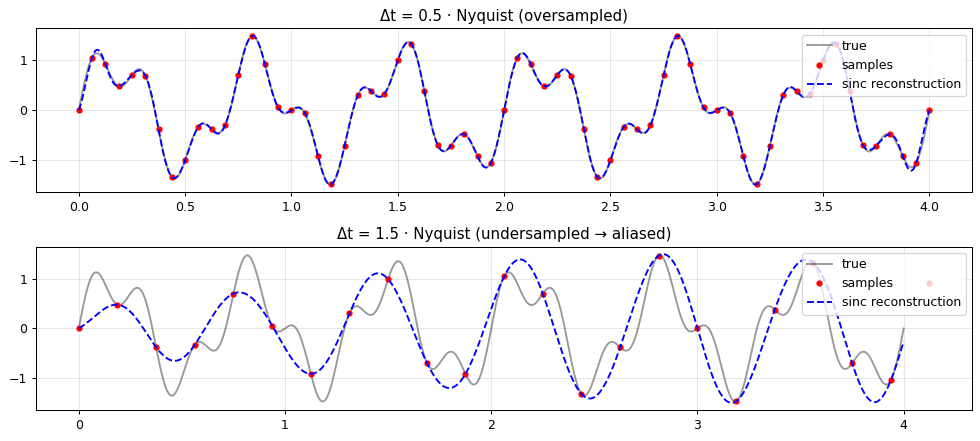

In [32]:
# True band-limited signal: sum of two sines, max freq = 4 Hz
true_freqs = [1.5, 4.0]
f_max = max(true_freqs)
nyquist_dt = 1 / (2 * f_max)

def signal_func(t):
    return np.sin(2*np.pi*1.5*t) + 0.5 * np.sin(2*np.pi*4.0*t)

def sinc_reconstruct(t_query, t_samples, h_samples, dt):
    arg = np.pi * (t_query[:, None] - t_samples[None, :]) / dt
    return np.sum(h_samples[None, :] * np.sinc(arg / np.pi), axis=1)

t_query = np.linspace(0, 4, 1000)
y_true  = signal_func(t_query)

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
for ax, dt_factor, label in zip(axes, [0.5, 1.5],
                                 ['Δt = 0.5 · Nyquist (oversampled)',
                                  'Δt = 1.5 · Nyquist (undersampled → aliased)']):
    dt = dt_factor * nyquist_dt
    t_s = np.arange(0, 4 + dt, dt)
    h_s = signal_func(t_s)
    y_rec = sinc_reconstruct(t_query, t_s, h_s, dt)
    ax.plot(t_query, y_true, 'k-', alpha=0.4, label='true')
    ax.plot(t_s, h_s, 'ro', label='samples', ms=4)
    ax.plot(t_query, y_rec, 'b--', label='sinc reconstruction')
    ax.set_title(label); ax.legend()
plt.tight_layout(); plt.show()

## 33. Discrete vs. true Fourier transform
> 📖 PDF pages 65–66

For a properly sampled, band-limited signal, $|H(f_k)| \approx \Delta t\, |H_k|$. We verify on a Gaussian, whose FT is known analytically.

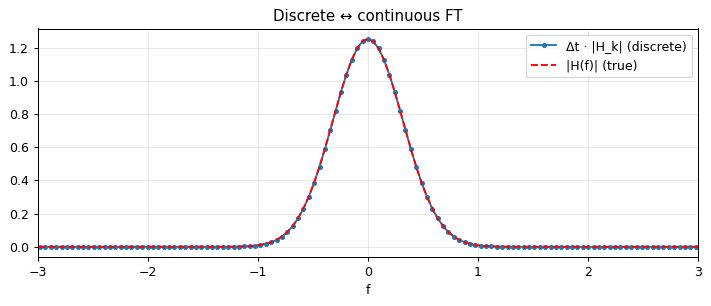

In [33]:
sigma_t = 0.5
N, dt = 512, 0.04
t = (np.arange(N) - N/2) * dt
h = np.exp(-t**2 / (2*sigma_t**2))

# Discrete FT
H_k = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h)))
f_k = np.fft.fftshift(np.fft.fftfreq(N, d=dt))

# True FT (analytical)
H_true = sigma_t * np.sqrt(2*np.pi) * np.exp(-2*np.pi**2*sigma_t**2 * f_k**2)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(f_k, dt * np.abs(H_k), 'o-', ms=3, label='Δt · |H_k| (discrete)')
ax.plot(f_k, H_true, 'r--', lw=1.5, label='|H(f)| (true)')
ax.set_xlim(-3, 3); ax.set_xlabel('f'); ax.set_title('Discrete ↔ continuous FT'); ax.legend()
plt.tight_layout(); plt.show()

## 34. Sampling window function (even)
> 📖 PDF pages 67–68

The sampling window is a comb of delta functions at the observation times. For even sampling, its FT is also a comb — spaced by $1/\Delta t$.

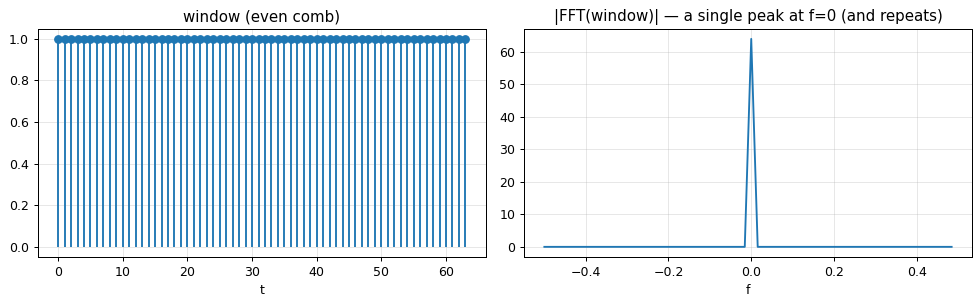

In [34]:
N, dt = 64, 1.0
t = np.arange(N) * dt
w = np.ones_like(t)                  # comb (1 at each sample)
W = np.fft.fftshift(np.fft.fft(w))
f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].stem(t, w, basefmt=' '); axes[0].set_title('window (even comb)')
axes[0].set_xlabel('t')
axes[1].plot(f, np.abs(W))
axes[1].set_title('|FFT(window)| — a single peak at f=0 (and repeats)')
axes[1].set_xlabel('f')
plt.tight_layout(); plt.show()

## 35. Sampling window function (uneven)
> 📖 PDF pages 69–70

With irregular sampling the spectral window is more complicated — it has sidelobes and aliases at the periodicities of the sampling pattern. These leak into the data PSD via convolution: $\widehat{H_{\rm data}}(f) = H_{\rm true} * H_{\rm window}(f)$.

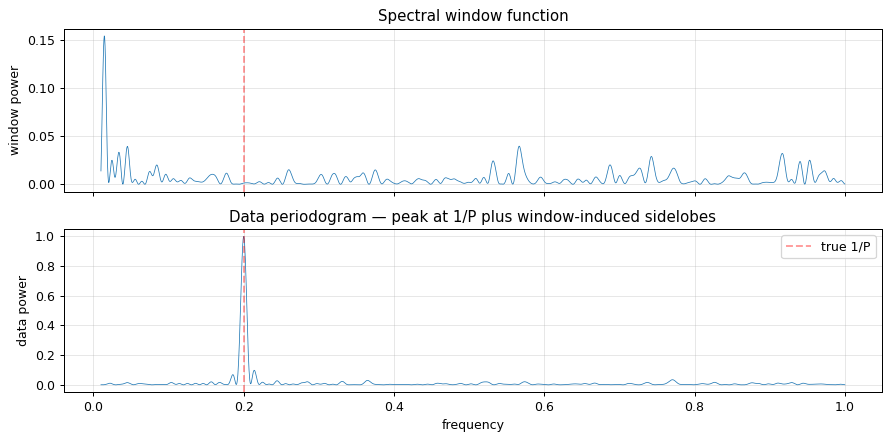

In [35]:
rng = np.random.default_rng(27)
# Uneven sampling: pick a random subset of a dense grid
T = 100.0
t_dense = np.linspace(0, T, 4000)
keep = rng.random(t_dense.size) > 0.92
t_obs = t_dense[keep]

# True signal
P_true = 5.0
y_obs = np.sin(2*np.pi*t_obs/P_true)

# Spectral window: LS power of the constant signal y=1 at the observation times
# (use fit_mean=False so we don't subtract the constant)
freq = np.linspace(0.01, 1.0, 2000)
_, window_power = lomb_scargle(t_obs, np.ones_like(t_obs), sigma=np.ones_like(t_obs),
                                freq=freq, fit_mean=False)
_, data_power   = lomb_scargle(t_obs, y_obs, sigma=np.ones_like(t_obs),
                                freq=freq, fit_mean=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(freq, window_power, lw=0.6)
axes[0].axvline(1/P_true, color='r', ls='--', alpha=0.4)
axes[0].set_ylabel('window power'); axes[0].set_title('Spectral window function')
axes[1].plot(freq, data_power, lw=0.6)
axes[1].axvline(1/P_true, color='r', ls='--', alpha=0.4, label='true 1/P')
axes[1].set_ylabel('data power'); axes[1].set_xlabel('frequency'); axes[1].legend()
axes[1].set_title('Data periodogram — peak at 1/P plus window-induced sidelobes')
plt.tight_layout(); plt.show()

## 36. Fast Fourier transform
> 📖 PDF pages 71–72

The FFT computes the DFT in $\mathcal{O}(N \log N)$ instead of $\mathcal{O}(N^2)$. Below we measure both on the same machine.

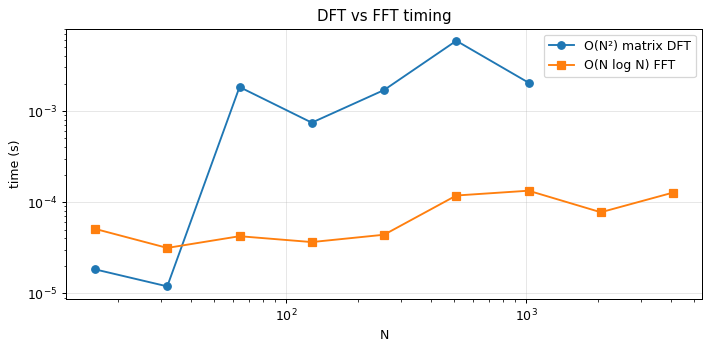

In [36]:
import time

sizes = [2**k for k in range(4, 13)]
t_dft, t_fft = [], []
for N in sizes:
    x = np.random.default_rng(0).normal(size=N)
    M = dft_matrix(N) if N <= 1024 else None
    if M is not None:
        t0 = time.perf_counter(); _ = M @ x; t_dft.append(time.perf_counter() - t0)
    else:
        t_dft.append(np.nan)
    t0 = time.perf_counter(); _ = np.fft.fft(x); t_fft.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(sizes, t_dft, 'o-', label='O(N²) matrix DFT')
ax.loglog(sizes, t_fft, 's-', label='O(N log N) FFT')
ax.set_xlabel('N'); ax.set_ylabel('time (s)')
ax.set_title('DFT vs FFT timing'); ax.legend()
plt.tight_layout(); plt.show()

## 37. Lomb–Scargle periodogram
> 📖 PDF pages 73–74

For unevenly sampled data, the Lomb–Scargle periodogram is the standard tool:
$$P_{LS}(\omega) = \frac{1}{2}\left[\frac{(\sum X_j \cos\omega(t_j-\tau))^2}{\sum \cos^2\omega(t_j-\tau)} + \frac{(\sum X_j \sin\omega(t_j-\tau))^2}{\sum \sin^2\omega(t_j-\tau)}\right]$$
where $\tau$ is the time offset that decouples the two sums. We use the helper `lomb_scargle()` (a thin wrapper around `scipy.signal.lombscargle`).

Best period from LS: 0.2997  (true = 0.3)


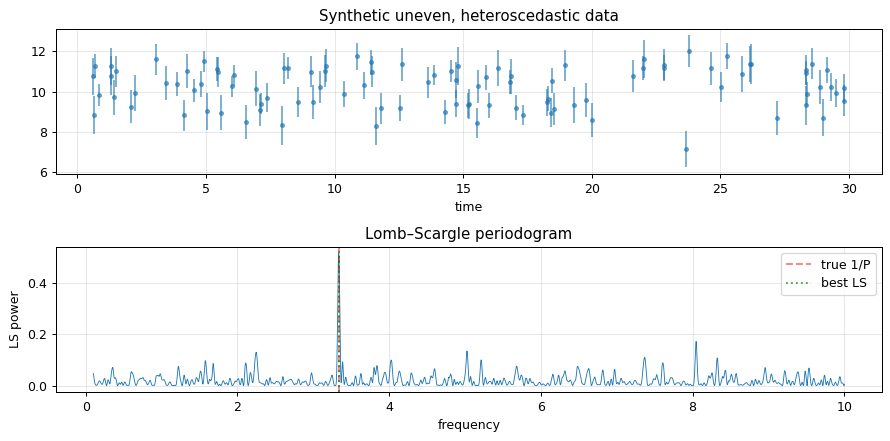

In [37]:
rng = np.random.default_rng(29)
n = 100
t = np.sort(rng.uniform(0, 30, n))
P_true = 0.3
sigma = rng.uniform(0.5, 1.0, n)
y = 10 + np.sin(2*np.pi*t/P_true) + sigma * rng.normal(size=n)

freq, power = lomb_scargle(t, y, sigma,
                           minimum_frequency=0.1, maximum_frequency=10,
                           samples_per_peak=10, fit_mean=True)
best_f = freq[int(np.argmax(power))]
print(f"Best period from LS: {1/best_f:.4f}  (true = {P_true})")

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].errorbar(t, y, yerr=sigma, fmt='.', alpha=0.6)
axes[0].set_title('Synthetic uneven, heteroscedastic data')
axes[0].set_xlabel('time')
axes[1].plot(freq, power, lw=0.7)
axes[1].axvline(1/P_true, color='r', ls='--', alpha=0.5, label='true 1/P')
axes[1].axvline(best_f,   color='g', ls=':',  alpha=0.7, label='best LS')
axes[1].set_xlabel('frequency'); axes[1].set_ylabel('LS power'); axes[1].legend()
axes[1].set_title('Lomb–Scargle periodogram')
plt.tight_layout(); plt.show()

## 38. Lomb–Scargle — false-alarm probability
> 📖 PDF pages 75–78

For pure noise, $\Pr(Z > z) = \exp(-z)$ at any single frequency. Across $N$ independent frequencies, the maximum follows $\Pr(Z_{\max} > z) = 1 - (1 - e^{-z})^N$. We verify both formulae with a Monte-Carlo experiment.

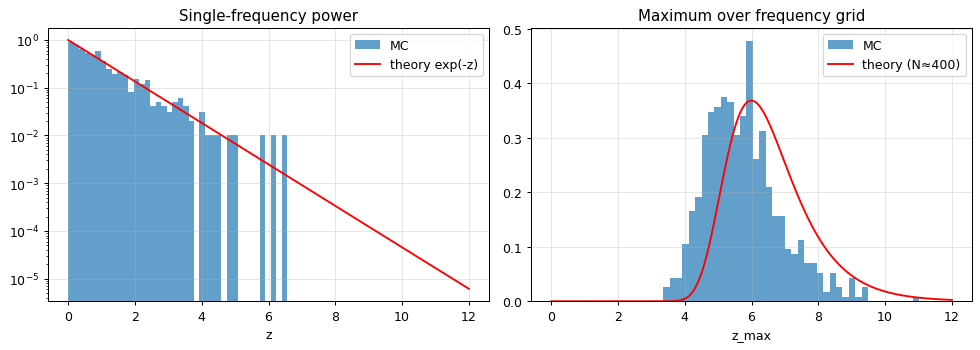

In [38]:
rng = np.random.default_rng(31)
n = 80
t_pat = np.sort(rng.uniform(0, 30, n))
sigma = np.ones(n)

# Build a frequency grid once
freq = np.linspace(0.1, 5.0, 400)
N_eff = len(freq)

n_trials = 600
single_powers = np.empty(n_trials)
max_powers    = np.empty(n_trials)
for i in range(n_trials):
    y = rng.normal(size=n)
    _, p = lomb_scargle(t_pat, y, sigma, freq=freq, fit_mean=False)
    # Under H0 (Gaussian noise), the normalized LS power is exp-distributed → z = power*(n-1)/2
    p_z = p * (n - 1) / 2.0
    single_powers[i] = p_z[0]
    max_powers[i]    = p_z.max()

zs = np.linspace(0, 12, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(single_powers, bins=40, density=True, alpha=0.7, label='MC')
axes[0].plot(zs, np.exp(-zs), 'r-', label='theory exp(-z)')
axes[0].set_yscale('log'); axes[0].set_xlabel('z'); axes[0].set_title('Single-frequency power')
axes[0].legend()

axes[1].hist(max_powers, bins=40, density=True, alpha=0.7, label='MC')
# pdf of max ≈ N(1-e^-z)^(N-1) e^-z   (independent-frequencies approximation)
pdf_max = N_eff * (1 - np.exp(-zs))**(N_eff - 1) * np.exp(-zs)
axes[1].plot(zs, pdf_max, 'r-', label=f'theory (N≈{N_eff})')
axes[1].set_xlabel('z_max'); axes[1].set_title('Maximum over frequency grid')
axes[1].legend()
plt.tight_layout(); plt.show()

## 39. Lomb–Scargle — practical grid choice
> 📖 PDF pages 79–80

Rule of thumb (VanderPlas 2018):
- $\omega_{\min} = 2\pi / (T_{\max} - T_{\min})$
- $\omega_{\max} = 2\pi / \langle\Delta t\rangle$ (loose; for irregular sampling the effective Nyquist can be higher)
- $\Delta\omega = \eta \omega_{\min}$ with $\eta \approx 0.1$

The helper's `samples_per_peak` sets the grid density: $\Delta f = (1/T)/\text{samples\_per\_peak}$. Below we show what happens with a deliberately too-coarse grid (the peak can fall between samples and be missed).

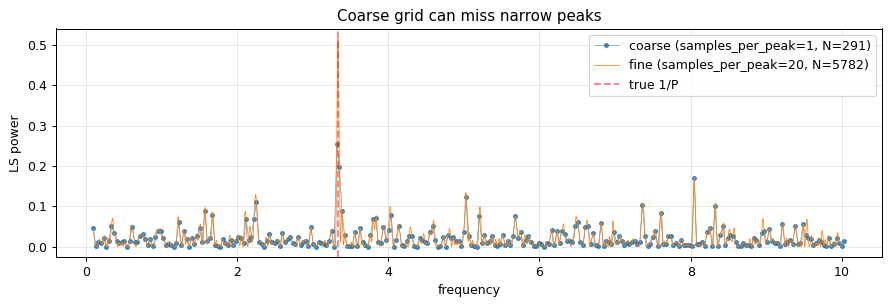

In [39]:
# Regenerate the synthetic dataset (same as §37) so this cell is self-contained
rng = np.random.default_rng(29)
n = 100
t = np.sort(rng.uniform(0, 30, n))
P_true = 0.3
sigma = rng.uniform(0.5, 1.0, n)
y = 10 + np.sin(2*np.pi*t/P_true) + sigma * rng.normal(size=n)

freq_coarse, power_coarse = lomb_scargle(t, y, sigma,
                                          minimum_frequency=0.1, maximum_frequency=10,
                                          samples_per_peak=1, fit_mean=True)
freq_fine,   power_fine   = lomb_scargle(t, y, sigma,
                                          minimum_frequency=0.1, maximum_frequency=10,
                                          samples_per_peak=20, fit_mean=True)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(freq_coarse, power_coarse, 'o-', ms=3, lw=0.5, alpha=0.8,
        label=f'coarse (samples_per_peak=1, N={len(freq_coarse)})')
ax.plot(freq_fine,   power_fine,   '-', lw=0.6,
        label=f'fine (samples_per_peak=20, N={len(freq_fine)})')
ax.axvline(1/P_true, color='r', ls='--', alpha=0.5, label='true 1/P')
ax.set_xlabel('frequency'); ax.set_ylabel('LS power')
ax.set_title('Coarse grid can miss narrow peaks'); ax.legend()
plt.tight_layout(); plt.show()

## 40. Generalized Lomb–Scargle
> 📖 PDF pages 82–83

The classical LS assumes the data mean is well-determined. The **generalized** LS (Zechmeister & Kürster 2009) fits an offset jointly with the sinusoid, which helps when the sampling window biases the empirical mean. In `scipy.signal.lombscargle` (and our `lomb_scargle` wrapper) this is `fit_mean=True` / `floating_mean=True`.

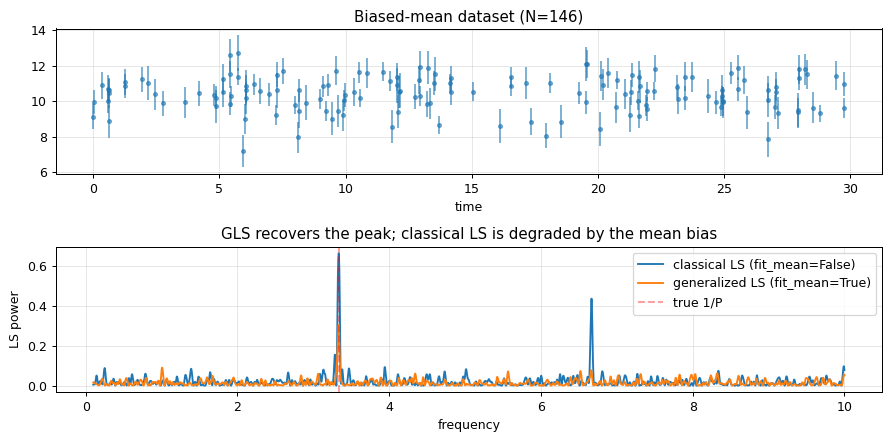

In [40]:
# Build a dataset whose sampling biases the empirical mean
rng = np.random.default_rng(33)
P_true = 0.3
# Draw lots of candidate times, keep more near phase 0 (biases the mean upward)
n_pool = 600
t_pool = np.sort(rng.uniform(0, 30, n_pool))
phase  = (t_pool % P_true) / P_true
keep   = rng.random(n_pool) < (0.05 + 0.7 * (phase < 0.25))
t      = t_pool[keep]
sigma  = rng.uniform(0.5, 1.0, t.size)
y      = 10 + np.sin(2*np.pi*t/P_true) + sigma * rng.normal(size=t.size)

freq = np.linspace(0.1, 10, 4000)
_, p_std = lomb_scargle(t, y, sigma, freq=freq, fit_mean=False)
_, p_gls = lomb_scargle(t, y, sigma, freq=freq, fit_mean=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].errorbar(t, y, yerr=sigma, fmt='.', alpha=0.6)
axes[0].set_title(f'Biased-mean dataset (N={t.size})'); axes[0].set_xlabel('time')
axes[1].plot(freq, p_std, label='classical LS (fit_mean=False)')
axes[1].plot(freq, p_gls, label='generalized LS (fit_mean=True)')
axes[1].axvline(1/P_true, color='r', ls='--', alpha=0.4, label='true 1/P')
axes[1].set_xlabel('frequency'); axes[1].set_ylabel('LS power'); axes[1].legend()
axes[1].set_title('GLS recovers the peak; classical LS is degraded by the mean bias')
plt.tight_layout(); plt.show()

## 41. Application — OGLE RR Lyrae (RRc, near-sinusoidal)
> 📖 PDF page 84

Real data: OGLE-IV `OGLE-BLG-RRLYR-01000`, an RRc-type RR Lyrae from the Galactic bulge. Catalogued period: **0.26013412 d**. We compute the Lomb–Scargle periodogram and phase-fold at the best period.

N = 2627 observations, span = 2696.8 d


LS best period: 0.2601340 d   (catalog: 0.26013412 d)


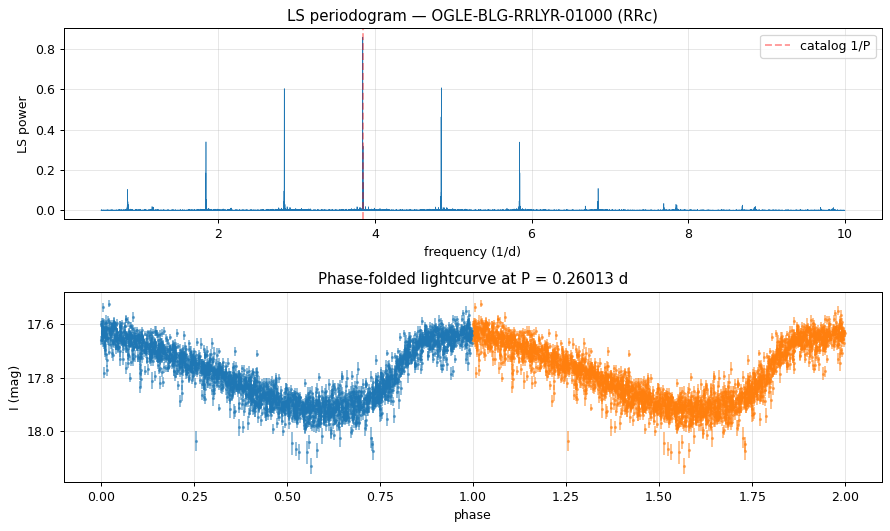

In [41]:
rrc = np.loadtxt(DATA / 'OGLE-BLG-RRLYR-01000.dat')
t_obs, mag, err = rrc[:, 0], rrc[:, 1], rrc[:, 2]
print(f"N = {len(t_obs)} observations, span = {np.ptp(t_obs):.1f} d")

freq, power = lomb_scargle(t_obs, mag, err,
                           minimum_frequency=0.5, maximum_frequency=10.0,
                           samples_per_peak=10, fit_mean=True)
best_f = freq[int(np.argmax(power))]
P_cat  = 0.26013412
print(f"LS best period: {1/best_f:.7f} d   (catalog: {P_cat} d)")

phase = ((t_obs - t_obs[0]) * best_f) % 1.0

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(freq, power, lw=0.5)
axes[0].axvline(1/P_cat, color='r', ls='--', alpha=0.4, label='catalog 1/P')
axes[0].set_xlabel('frequency (1/d)'); axes[0].set_ylabel('LS power')
axes[0].set_title(f'LS periodogram — OGLE-BLG-RRLYR-01000 (RRc)'); axes[0].legend()

axes[1].errorbar(phase, mag, yerr=err, fmt='.', ms=3, alpha=0.5)
axes[1].errorbar(phase + 1, mag, yerr=err, fmt='.', ms=3, alpha=0.5)
axes[1].invert_yaxis(); axes[1].set_xlabel('phase'); axes[1].set_ylabel('I (mag)')
axes[1].set_title(f'Phase-folded lightcurve at P = {1/best_f:.5f} d')
plt.tight_layout(); plt.show()

## 42. Truncated Fourier / multi-term LS — OGLE RRab sawtooth
> 📖 PDF pages 85–86

RRab lightcurves have a sharply asymmetric (sawtooth) shape — a single sinusoid is a poor fit. The truncated Fourier series model adds harmonics: $y(t) = c + \sum_{k=1}^{K} [A_k \sin(2\pi k t/P) + B_k \cos(2\pi k t/P)]$.

The helpers `multiterm_power()` and `multiterm_model()` (defined in §Setup) implement this as a weighted linear least-squares fit at each candidate frequency. We use OGLE-IV `OGLE-BLG-RRLYR-05000`, period **0.49725278 d**.

LS best period: 0.4972605 d   (catalog: 0.49725278 d)


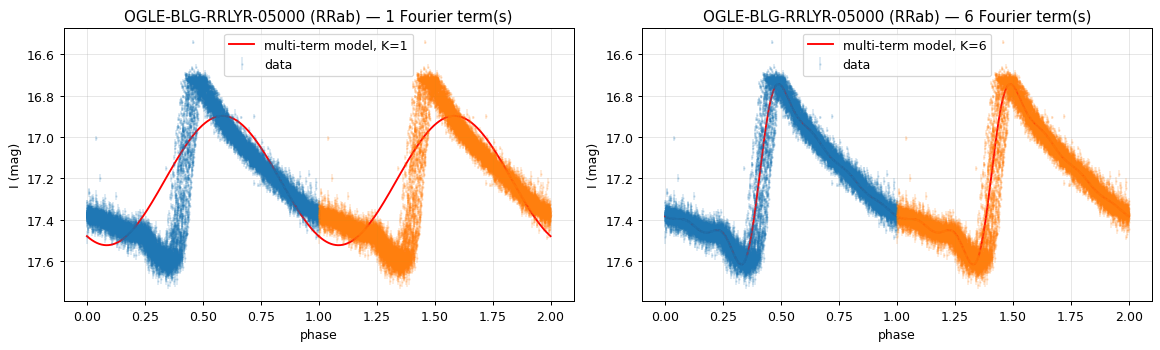

In [42]:
rrab = np.loadtxt(DATA / 'OGLE-BLG-RRLYR-05000.dat')
t_obs, mag, err = rrab[:, 0], rrab[:, 1], rrab[:, 2]
P_cat = 0.49725278

# Subsample to keep the multi-term scan fast (this star has ~14k obs)
rng = np.random.default_rng(0)
idx = rng.choice(len(t_obs), size=1500, replace=False); idx.sort()
t_s, mag_s, err_s = t_obs[idx], mag[idx], err[idx]

# Single-term LS to find the period
freq, power = lomb_scargle(t_s, mag_s, err_s,
                           minimum_frequency=0.5, maximum_frequency=5.0,
                           samples_per_peak=5, fit_mean=True)
best_f = freq[int(np.argmax(power))]
print(f"LS best period: {1/best_f:.7f} d   (catalog: {P_cat} d)")

# Compare 1-term and multi-term reconstructions of the folded lightcurve
phase_grid = np.linspace(0, 1, 400)
t_model = t_obs[0] + phase_grid / best_f
phase   = ((t_obs - t_obs[0]) * best_f) % 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, K in zip(axes, [1, 6]):
    y_model = multiterm_model(t_s, mag_s, err_s, best_f, K, t_model)
    ax.errorbar(phase, mag, yerr=err, fmt='.', ms=2, alpha=0.15, label='data')
    ax.errorbar(phase + 1, mag, yerr=err, fmt='.', ms=2, alpha=0.15)
    ax.plot(phase_grid, y_model, 'r-', lw=1.5, label=f'multi-term model, K={K}')
    ax.plot(phase_grid + 1, y_model, 'r-', lw=1.5)
    ax.invert_yaxis()
    ax.set_xlabel('phase'); ax.set_ylabel('I (mag)')
    ax.set_title(f'OGLE-BLG-RRLYR-05000 (RRab) — {K} Fourier term(s)')
    ax.legend()
plt.tight_layout(); plt.show()

## 42b. Multi-band period distributions from ZTF (ALeRCE)
> Application — real-data period-finding on a population

The [**ALeRCE broker**](https://alerce.online) classifies every ZTF alert in real time. We queried its
LC classifier for 60 high-confidence RR Lyrae (RRL) and 60 high-confidence Cepheids (CEP),
downloaded their ZTF $g$- and $r$-band photometry, and computed a **multi-band Lomb–Scargle period**
(single frequency shared across bands, separate offset/amplitude per band — the sum-of-z-powers
combination of two per-band scipy LS evaluations). Caching this is done once by
`fetch_alerce.py`; the notebook just loads the result.

Note: most ALeRCE Cepheids in our sample have only $g$-band detections in ZTF (filter coverage
varies by field). The histograms below still reproduce the expected period distributions: RR Lyrae
cluster around ~0.3–0.7 d, classical Cepheids span ~1–60 d.

In [43]:
# Load the cached ALeRCE result
cache = DATA / 'alerce_variables.json'
if not cache.exists():
    raise FileNotFoundError(
        f'Run `python3 fetch_alerce.py` once to create {cache}'
    )
with open(cache) as f:
    alerce = json.load(f)

df = pd.DataFrame([{
    'oid':       x['oid'],
    'class':     x['class'],
    'period':    x['period'],
    'n_g':       x['ndet_g'],
    'n_r':       x['ndet_r'],
    'multiband': len(x['bands_used']) > 1,
} for x in alerce])

print(df.groupby('class').agg(
    n=('oid', 'count'),
    median_P=('period', 'median'),
    P_25th=('period', lambda s: s.quantile(0.25)),
    P_75th=('period', lambda s: s.quantile(0.75)),
    multiband_frac=('multiband', 'mean'),
).round(3))

        n  median_P  P_25th  P_75th  multiband_frac
class                                              
CEP    60     4.739   3.327   6.211           0.183
RRL    60     0.528   0.475   0.562           1.000


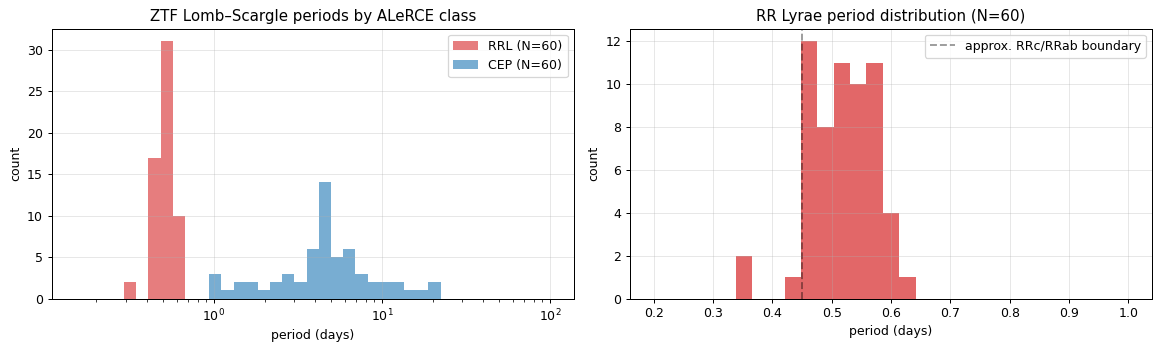

In [44]:
# Period histograms on a log axis (periods span orders of magnitude)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.geomspace(0.15, 100, 40)
for cls, color in [('RRL', 'C3'), ('CEP', 'C0')]:
    sub = df[df['class'] == cls]
    axes[0].hist(sub.period, bins=bins, alpha=0.6, color=color,
                 label=f'{cls} (N={len(sub)})')
axes[0].set_xscale('log')
axes[0].set_xlabel('period (days)'); axes[0].set_ylabel('count')
axes[0].set_title('ZTF Lomb–Scargle periods by ALeRCE class')
axes[0].legend()

# Zoom on RRL alone with finer bins
sub = df[df['class'] == 'RRL']
axes[1].hist(sub.period, bins=np.linspace(0.2, 1.0, 30),
             alpha=0.7, color='C3')
axes[1].set_xlabel('period (days)'); axes[1].set_ylabel('count')
axes[1].set_title(f'RR Lyrae period distribution (N={len(sub)})')
axes[1].axvline(0.45, color='k', ls='--', alpha=0.4,
                label='approx. RRc/RRab boundary')
axes[1].legend()
plt.tight_layout(); plt.show()

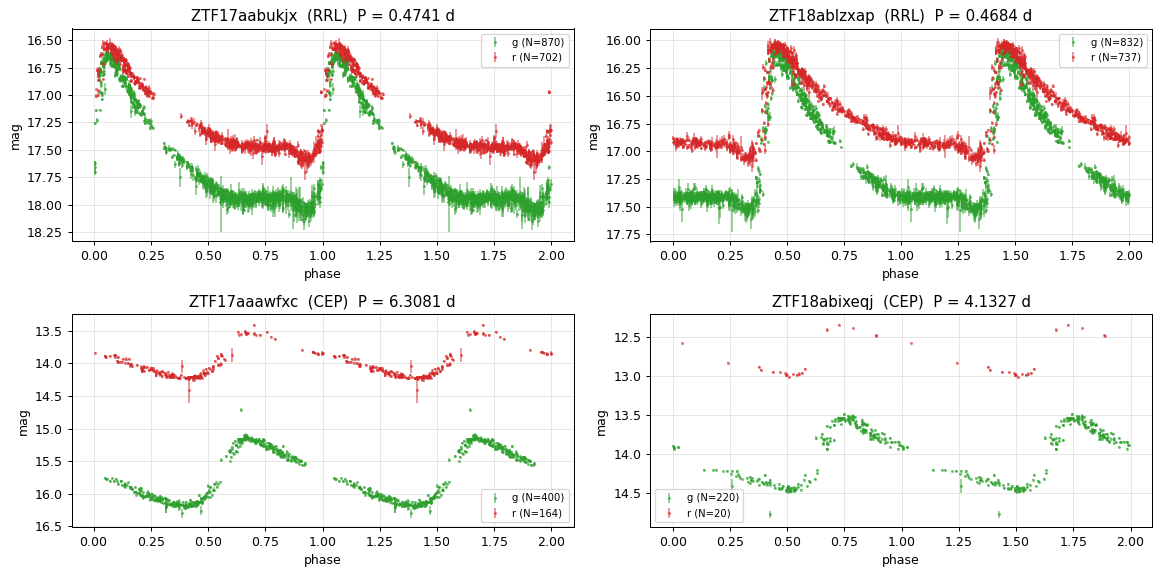

In [45]:
# Example folded lightcurves: pick 2 RRL and 2 CEP, prefer ones with both bands
def example_oids(df, alerce, cls, n):
    sub = df[df['class'] == cls].copy()
    sub['n_min'] = sub[['n_g', 'n_r']].min(axis=1)
    chosen = sub.sort_values('n_min', ascending=False).head(n)['oid'].tolist()
    return [next(x for x in alerce if x['oid'] == oid) for oid in chosen]

examples = example_oids(df, alerce, 'RRL', 2) + example_oids(df, alerce, 'CEP', 2)

SIGMA_MAX = 0.3   # drop noisy detections that would stretch the magnitude axis

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
for ax, obj in zip(axes.flat, examples):
    P = obj['period']
    # Common reference epoch for ALL bands (otherwise g and r get
    # offset by a random phase because their first MJDs differ).
    t_ref = min(min(obj[f't_{l}']) for l in 'gr' if obj[f't_{l}'])
    for letter, color in [('g', 'C2'), ('r', 'C3')]:
        t = np.array(obj[f't_{letter}'])
        y = np.array(obj[f'y_{letter}'])
        s = np.array(obj[f's_{letter}'])
        if t.size == 0:
            continue
        keep = s < SIGMA_MAX
        t, y, s = t[keep], y[keep], s[keep]
        if t.size == 0:
            continue
        ph = ((t - t_ref) / P) % 1.0
        ax.errorbar(ph, y, yerr=s, fmt='.', ms=3, alpha=0.5,
                    label=f'{letter} (N={t.size})', color=color)
        ax.errorbar(ph + 1, y, yerr=s, fmt='.', ms=3, alpha=0.5, color=color)
    ax.invert_yaxis()
    ax.set_xlabel('phase'); ax.set_ylabel('mag')
    ax.set_title(f'{obj["oid"]}  ({obj["class"]})  P = {P:.4f} d')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 43. Summary
> 📖 PDF page 87

- Astronomical timeseries are **unevenly sampled**, have **heteroscedastic errors**, and are often **low-SNR**.
- Key tools introduced in Part I (autocorrelated, non-periodic variability):
  - ACF / PACF / Durbin–Watson for diagnosis
  - AR / MA / ARMA family, with AIC/BIC for model order
  - CARMA and IAR for irregular sampling
- Key tools introduced in Part II (periodic variability):
  - Continuous & discrete Fourier transforms, Nyquist, window functions
  - **Generalized Lomb–Scargle** for unevenly sampled, heteroscedastic data
  - **Multi-term LS / truncated Fourier** when the lightcurve has a non-sinusoidal shape

References used in the notebook:
- VanderPlas 2018, *Understanding the Lomb–Scargle Periodogram*
- Eyheramendy et al. 2018 (IAR), Kelly et al. 2014 (CARMA)
- Zechmeister & Kürster 2009 (generalized LS)
- OGLE-IV Collection of Variable Stars — Soszyński et al.
